# Task 1 – Data Understanding and Preparation

## Objective
Build a reliable analytical dataset by integrating artist-level and track-level data, validating data quality, engineering interpretable features, and identifying non-redundant variables for downstream modeling.

## Task 1 Workflow Summary

### Phase 1: Data Ingestion and Merge Validation
Load the two source datasets and verify a correct one-to-many merge between artists and tracks.

**Key actions:**
- Load `artists.csv` (semicolon-separated) and `tracks.csv` (comma-separated)
- Merge on artist identifier with one-to-many validation
- Check coverage and cardinality consistency

**Checks performed:**
- Number of rows and features before/after merge
- Unique artists and songs preserved
- Merge coverage percentage against original tracks table

### Phase 2: Schema Understanding and Semantic Grouping
Map variables to semantic families to make EDA and feature decisions traceable.

**Key actions:**
- Build feature group table by level and domain
- Summarize number of variables per group
- Keep engineered feature documentation table for reproducibility

### Phase 3: Text Redundancy Resolution
Detect near-duplicate text fields and retain the most informative representation.

**Decisions taken:**
- Drop `album`, keep `album_name` (lower missingness)
- Drop `title`, keep `full_title` (richer context)

**Method:**
- Pairwise text similarity comparison over non-null overlaps
- Decision table with motivation for each dropped column

### Phase 4: Cleaning, Typing, and Date Construction
Standardize values and enforce consistent datatypes to avoid downstream leakage and parsing errors.

**Key actions:**
- Convert numeric columns with coercion on invalid values
- Parse date columns (`birth_date`, `active_start`, `active_end`, `album_release_date`)
- Normalize `explicit` and derive numeric version
- Build `track_release_date` from year/month/day
- Derive robust `release_year` from track date with album-date fallback

### Phase 5: Data Quality Diagnostics
Assess missingness, duplicates, invalid values, and out-of-domain observations.

**Quality checks performed:**
- Missing values by feature and by semantic group
- Duplicate song IDs, duplicate rows, duplicate artist-title pairs
- Artist name inconsistencies
- Invalid or implausible dates
- Domain-rule violations (e.g., popularity bounds, bpm and duration limits)
- Robust outlier summaries using statistical and rule-based criteria

### Phase 6: Feature Engineering
Create interpretable features aligned with project goals and ready for modeling.

**Engineered features include:**
- `swear_total`, `swear_density_total`
- `artist_macroarea`
- `sentence_complexity_index`
- `artist_song_count`
- `audio_signature_score`
- `release_recency_years`
- `engagement_ratio`
- `explicit_content_intensity`
- `artist_consistency_score`
- `lyric_audio_balance`
- `artist_geographic_diversity`
- `mood_label` (valence-arousal MER-inspired proxy)

### Phase 7: Exploratory Analysis and Interpretability
Analyze distributions and key relationships to ground model choices.

**Exploration performed:**
- Histograms, boxplots, and violin plots for core variables
- Log-transformed inspection for skewed distributions
- Regional comparison of profanity density
- Geographic diversity analysis at artist level
- Mood-label profiling versus swear density and geographic deviation

### Phase 8: Correlation and Redundancy Reduction
Identify multicollinearity and select a compact feature subset for modeling.

**Method:**
- Pearson and Spearman correlation matrices
- High-correlation pair extraction
- Correlation-group discovery and scoring-based selection
- Keep anchor feature per group, optionally keep one secondary if signal is distinct

**Output:**
- Group-level keep/drop decisions with documented rationale
- Final selected feature subset for next tasks

---

## Task 1 Deliverables

- Merged and cleaned working dataframe
- Data quality diagnostics tables (missingness, duplicates, outliers, invalid dates)
- Engineered feature set with motivations
- EDA visual outputs and interpretation notes
- Correlation-aware non-redundant feature subset for modeling

In [74]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from IPython.display import display

import functions as uf

%load_ext autoreload
%autoreload 2

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="talk")

candidate_dirs = [Path.cwd().parent / "dataset", Path.cwd() / "dataset"]
DATA_DIR = next((path for path in candidate_dirs if (path / "artists.csv").exists() and (path / "tracks.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the repo-level dataset/ directory.")

print(f"Using data directory: {DATA_DIR.resolve()}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using data directory: /home/simone/ML_first_project/dataset


In [75]:
# Optional: Helper function for loading context datasets (comparative analysis)
def load_context_dataset(dataset_name: str) -> pd.DataFrame:
    """
    Load reference datasets from notebooks_context/Dataset/ for comparative analysis.
    
    Parameters
    ----------
    dataset_name : str
        Name of dataset without extension. Available options:
        - 'iris': UCI Iris classification (150 samples, 4 numeric features, 3 classes)
        - 'titanic': Kaggle Titanic survival prediction (891 samples, mixed types, binary target)
        - 'hotel_bookings': Hotel booking demand (119,390 samples, hotel features)
        - 'abalone': Abalone age prediction (4,177 samples, physical measurements)
        - 'adult_clean': UCI Adult income classification (pre-cleaned, mixed types)
    
    Returns
    -------
    pd.DataFrame
        Loaded dataset as pandas DataFrame
    
    Examples
    --------
    >>> iris = load_context_dataset('iris')
    >>> titanic = load_context_dataset('titanic')
    """
    context_dataset_dir = Path(__file__).parent.parent / "notebooks_context" / "Dataset"
    dataset_path = context_dataset_dir / f"{dataset_name}.csv"
    
    if not dataset_path.exists():
        available = [f.stem for f in context_dataset_dir.glob("*.csv")]
        raise FileNotFoundError(
            f"Dataset '{dataset_name}' not found at {dataset_path}.\n"
            f"Available datasets: {', '.join(sorted(available))}"
        )
    
    return pd.read_csv(dataset_path)

## Load The Raw Datasets

**Data Loading Strategy:**
- `artists.csv`: Artist-level metadata (semicolon-separated)
- `tracks.csv`: Track/song-level data with features and lyrics (comma-separated)

The notebook uses intelligent path resolution to work from any directory:
1. First checks parent directory: `../dataset/`
2. Falls back to current directory: `./dataset/`
3. Raises clear error if neither location has the required files

**Cross-reference datasets available:** For comparative analysis, context datasets (iris, titanic, hotel_bookings, abalone, adult_clean) are available in `notebooks_context/Dataset/`


In [76]:
df_artist = pd.read_csv(DATA_DIR / "artists.csv", sep=";")
df_track = pd.read_csv(DATA_DIR / "tracks.csv", sep=",")

print(f"Artists shape: {df_artist.shape}")
print(f"Tracks shape: {df_track.shape}")

display(df_artist.head())
display(df_track.head(2))


Artists shape: (104, 14)
Tracks shape: (11166, 45)


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN


,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,swear_IT,swear_EN,swear_IT_words,swear_EN_words,year,month,day,n_sentences,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,rms,zcr,flatness,spectral_complexity,pitch,loudness,album_name,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...","['bitch', 'fuck', 'porno', 'pussy']",2021.0,4.0,2.0,102.0,911.0,8.931373,4.170455,0.575284,8.133929,135.32,0.1858,2895.7767,1.4499,0.1786,0.1046,0.8202,25.7148,2311.1779,17.8675,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
1,TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...","['escort', 'negro', 'sex', 'sexy', 'shit']",2020.0,3.0,6.0,56.0,675.0,12.053571,4.280851,0.648936,12.500000,129.37,0.2071,3378.4605,1.3533,0.2020,0.1175,0.6739,29.1089,1892.1924,21.4595,FOREVER AND EVER,2021-04-09,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False


## Merge Validation And Dataset Overview

We merge artist-level and song-level data using the artist identifier, then verify coverage and summarize the variables by semantic role.


In [77]:
df = pd.merge(
    df_artist,
    df_track,
    left_on="id_author",
    right_on="id_artist",
    validate="one_to_many",
).rename(columns={"id": "id_song"})

merge_overview = pd.DataFrame(
    {
        "metric": [
            "artist_rows",
            "track_rows",
            "merged_rows",
            "unique_artists_in_artists",
            "unique_artists_in_tracks",
            "unique_artists_after_merge",
            "unique_song_ids_after_merge",
            "artist_features",
            "track_features",
            "merged_features",
            "merge_coverage_pct",
        ],
        "value": [
            len(df_artist),
            len(df_track),
            len(df),
            df_artist["id_author"].nunique(),
            df_track["id_artist"].nunique(),
            df["id_author"].nunique(),
            df["id_song"].nunique(),
            df_artist.shape[1],
            df_track.shape[1],
            df.shape[1],
            round(100 * len(df) / len(df_track), 2),
        ],
    }
)

display(merge_overview)
print(f"Expected working dataset: {len(df)} rows over {df['id_author'].nunique()} artists.")


,metric,value
0,artist_rows,104.0
1,track_rows,11166.0
2,merged_rows,11166.0
3,unique_artists_in_artists,104.0
4,unique_artists_in_tracks,104.0
5,unique_artists_after_merge,104.0
6,unique_song_ids_after_merge,11093.0
7,artist_features,14.0
8,track_features,45.0
9,merged_features,59.0


Expected working dataset: 11166 rows over 104 artists.


In [78]:
feature_group_table = uf.feature_group_table(df).sort_values(["level", "group", "feature"]).reset_index(drop=True)
feature_group_summary = (
    feature_group_table.groupby(["level", "group"])
    .size()
    .rename("n_features")
    .reset_index()
)
engineered_docs = uf.engineered_feature_table()

display(feature_group_summary)
display(feature_group_table)
display(engineered_docs)


,level,group,n_features
0,artist,artist_level,7
1,artist,geographic,7
2,song,audio,10
3,song,song_level,25
4,song,textual,10


,feature,group,level
0,active_end,artist_level,artist
1,active_start,artist_level,artist
2,birth_date,artist_level,artist
3,description,artist_level,artist
4,gender,artist_level,artist
5,id_author,artist_level,artist
6,name,artist_level,artist
7,birth_place,geographic,artist
8,country,geographic,artist
9,latitude,geographic,artist


,feature,family,role,description
0,swear_IT,textual,provided feature,Count of Italian swear words detected in the l...
1,swear_EN,textual,provided feature,Count of English swear words detected in the l...
2,swear_IT_words,textual,provided feature,List of matched Italian swear words found in t...
3,swear_EN_words,textual,provided feature,List of matched English swear words found in t...
4,n_sentences,textual,provided feature,Number of detected sentences in the lyrics.
5,n_tokens,textual,provided feature,Number of detected tokens/words in the lyrics.
6,tokens_per_sent,textual,provided feature,Average number of tokens per sentence.
7,char_per_tok,textual,provided feature,Average number of characters per token.
8,lexical_density,textual,provided feature,Ratio of lexical words over all tokens.
9,avg_token_per_clause,textual,provided feature,Average number of tokens per clause.


## Redundant Text Fields

Before deeper analysis, we check the overlap between duplicated textual columns and keep the richer representation when redundancy is high.


In [79]:
print(f"NaN in 'album': {df['album'].isna().sum()}")
print(f"NaN in 'album_name': {df['album_name'].isna().sum()}")
album_comparison, album_score = uf.compare_text_columns(df, "album", "album_name")

title_comparison, title_score = uf.compare_text_columns(df, "title", "full_title")

redundancy_summary = pd.DataFrame(
    [
        {
            "pair": "album vs album_name",
            "rows_evaluated": len(album_comparison),
            "avg_similarity": round(album_score, 2),
            "decision": "drop album",
            "motivation": "album_name has far fewer missing values",
        },
        {
            "pair": "title vs full_title",
            "rows_evaluated": len(title_comparison),
            "avg_similarity": round(title_score, 2),
            "decision": "drop title",
            "motivation": "full_title preserves featured-artist context",
        },
    ]
)

display(redundancy_summary)
display(album_comparison.nsmallest(10, "similarity_score"))
display(title_comparison.nsmallest(10, "similarity_score"))

df = df.drop(columns=["album", "title"])


NaN in 'album': 1514
NaN in 'album_name': 78


,pair,rows_evaluated,avg_similarity,decision,motivation
0,album vs album_name,9579,79.88,drop album,album_name has far fewer missing values
1,title vs full_title,11166,98.73,drop title,full_title preserves featured-artist context


,album,album_name,similarity_score
688,Lezioni di Volo,6AM,0.0
694,Lezioni di Volo,12,0.0
910,Seven: The Street Prequel,KG,0.0
1140,Ancora3cmdiossigeno,70 x 70,0.0
1432,Zappa,?!,0.0
1434,Ricomincio da Capa,?!,0.0
1438,Ricomincio da Capa,?!,0.0
1463,Zappa,?!,0.0
1470,Zappa,?!,0.0
1957,1998,Mal di te,0.0


,title,full_title,similarity_score
100,Ammo’,Ammo' by Achille Lauro (Ft. Clementino & Rocco...,14.035088
550,I’&I’,I'&I' by Babaman (Ft. Stevie Deville),14.285714
8421,“El Padre”,"""El Padre"" by Noyz Narcos & Fritz Da Cat",20.000000
851,Com’era,Com'era by Bassi Maestro & DJ Shocca (Ft. Anag...,20.689655
6536,Alfredo’s,"Alfredo's by MadMan (Ft. Ill Nacho, Lil' Pin, ...",21.621622
4047,L’inutile,L'inutile by Frankie hi-nrg mc (Ft. Paola Cort...,25.806452
6802,L’Albatro,L'Albatro by Marracash (Ft. Dargen D'Amico & R...,25.806452
4794,L’Amore,L'Amore by Ghemon (Ft. Frank Siciliano),26.086957
339,M’ama,M'ama by Alfa (Ft. Ytema),26.666667
9427,L’ODIO,L'ODIO by Salmo & Noyz Narcos,28.571429


## Cleaning, Typing, And Derived Dates

We standardize missing values, coerce numeric/date columns, validate boolean fields, and derive a cleaned release year for later analysis.


In [80]:
df = df.replace(r"^\s*$", np.nan, regex=True)

numeric_columns = [
    "stats_pageviews",
    "swear_IT",
    "swear_EN",
    "year",
    "month",
    "day",
    "n_sentences",
    "n_tokens",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "avg_token_per_clause",
    "bpm",
    "centroid",
    "rolloff",
    "flux",
    "rms",
    "zcr",
    "flatness",
    "spectral_complexity",
    "pitch",
    "loudness",
    "disc_number",
    "track_number",
    "duration_ms",
    "popularity",
    "modified_popularity",
    "latitude",
    "longitude",
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

for column in ["birth_date", "active_start", "active_end", "album_release_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")

explicit_map = {True: True, False: False, "True": True, "False": False}
df["explicit"] = df["explicit"].map(explicit_map)
df["explicit_numeric"] = df["explicit"].astype("float")

current_year = pd.Timestamp.today().year
plausible_track_year = df["year"].between(1900, current_year + 1)
plausible_album_year = df["album_release_date"].dt.year.between(1900, current_year + 1)

df["track_release_date"] = pd.to_datetime(
    {
        "year": df["year"],
        "month": df["month"],
        "day": df["day"],
    },
    errors="coerce",
)

df["release_year"] = df["year"].where(plausible_track_year)
df["release_year"] = df["release_year"].fillna(df["album_release_date"].dt.year.where(plausible_album_year))

display(df[["birth_date", "active_start", "active_end", "album_release_date", "track_release_date", "release_year"]].head())


,birth_date,active_start,active_end,album_release_date,track_release_date,release_year
0,NaT,1991-01-01,NaT,1993-06-12,NaT,1993.0
1,NaT,1991-01-01,NaT,1993-06-12,1993-06-12,1993.0
2,NaT,1991-01-01,NaT,1993-06-12,1993-06-12,1993.0
3,NaT,1991-01-01,NaT,NaT,NaT,1998.0
4,NaT,1991-01-01,NaT,2014-03-25,2014-03-25,2014.0


## Missing Values

The table below summarizes missingness by feature and by semantic group so that later modeling choices can separate structural missingness from optional metadata.


,feature,missing_count,missing_pct,group,level
0,active_end,11166,100.00,artist_level,artist
1,featured_artists,7649,68.50,song_level,song
2,stats_pageviews,6524,58.43,song_level,song
3,active_start,4601,41.21,artist_level,artist
4,region,3142,28.14,geographic,artist
5,province,2699,24.17,geographic,artist
6,country,2699,24.17,geographic,artist
7,nationality,2609,23.37,geographic,artist
8,birth_date,2578,23.09,artist_level,artist
9,birth_place,2578,23.09,geographic,artist


,level,group,avg_missing_count,avg_missing_pct
0,artist,artist_level,2783.285714,24.927143
1,artist,geographic,2697.571429,24.160000
4,song,song_level,792.652174,7.099565
3,song,derived,489.666667,4.386667
2,song,audio,64.000000,0.570000
5,song,textual,45.600000,0.408000


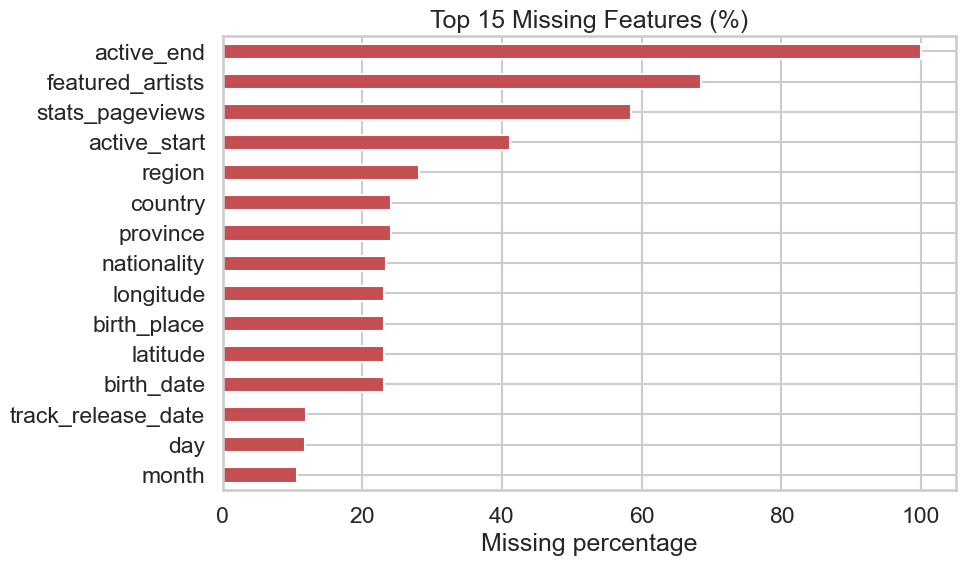

In [81]:
feature_lookup = uf.feature_group_table(df).drop_duplicates(subset=["feature"]).set_index("feature")
missing_summary = pd.DataFrame(
    {
        "feature": df.columns,
        "missing_count": df.isna().sum().values,
    }
)
missing_summary["missing_pct"] = (100 * missing_summary["missing_count"] / len(df)).round(2)
missing_summary = missing_summary.join(feature_lookup[["group", "level"]], on="feature")
missing_summary = missing_summary.fillna({"group": "derived", "level": "song"})
missing_summary = missing_summary.sort_values(["missing_pct", "missing_count"], ascending=False).reset_index(drop=True)

group_missing = (
    missing_summary.groupby(["level", "group"])[["missing_count", "missing_pct"]]
    .mean()
    .rename(columns={"missing_count": "avg_missing_count", "missing_pct": "avg_missing_pct"})
    .reset_index()
    .sort_values("avg_missing_pct", ascending=False)
)

display(missing_summary)
display(group_missing)

fig, ax = plt.subplots(figsize=(10, 6))
missing_summary.head(15).sort_values("missing_pct").plot.barh(
    x="feature",
    y="missing_pct",
    ax=ax,
    legend=False,
    color="#c44e52",
)
ax.set_title("Top 15 Missing Features (%)")
ax.set_xlabel("Missing percentage")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Duplicates And Inconsistent Values

We inspect duplicate identifiers, repeated merged rows, repeated artist-title combinations, and potentially inconsistent categorical labels.


In [82]:
duplicate_song_id_mask = df["id_song"].duplicated(keep=False)
duplicate_row_mask = df.duplicated(keep=False)
duplicate_artist_title_mask = df.duplicated(subset=["name", "full_title"], keep=False)

normalized_name_artist = df["name_artist"].map(uf.normalize_text)
normalized_name = df["name"].map(uf.normalize_text)
artist_name_mismatch_mask = normalized_name_artist != normalized_name

duplicates_summary = pd.DataFrame(
    [
        {"check": "duplicated_song_ids", "count": int(duplicate_song_id_mask.sum())},
        {"check": "fully_duplicated_rows", "count": int(duplicate_row_mask.sum())},
        {"check": "duplicated_artist_full_title_pairs", "count": int(duplicate_artist_title_mask.sum())},
        {"check": "artist_name_mismatches", "count": int(artist_name_mismatch_mask.sum())},
    ]
)

display(duplicates_summary)
display(
    df.loc[duplicate_song_id_mask, ["id_song", "name", "full_title", "album_name", "release_year"]]
    .sort_values(["id_song", "release_year"])
    .head(20)
)
display(
    df.loc[artist_name_mismatch_mask, ["name", "name_artist", "full_title"]]
    .drop_duplicates()
    .head(20)
)


,check,count
0,duplicated_song_ids,144
1,fully_duplicated_rows,0
2,duplicated_artist_full_title_pairs,4
3,artist_name_mismatches,872


,id_song,name,full_title,album_name,release_year
8414,TR108862,noyz narcos,SPINE by Noyz Narcos (Ft. Coez),VIRUS,1932.0
848,TR108862,bassi maestro,Sushi Bar by Bassi Maestro,Sushi - EP,2007.0
4771,TR135764,ghemon,Nessuno vale quanto te by Ghemon,ORCHIdee,2014.0
2992,TR135764,emis killa,Giovani eroi by Emis Killa (Ft. Not Good),"Keta Music, Vol. 3",2021.0
2013,TR190585,coez,Nei treni la notte by Coez (Ft. Frah Quintale),From The Rooftop 2,2022.0
8617,TR190585,piotta,Serpico by Piotta (Ft. Tiromancino),'na notte infame,2024.0
5912,TR192351,jake la furia,Musica Commerciale by Jake La Furia,Musica Commerciale,2013.0
1917,TR192351,club dogo,Tornerò Da Re - Redrum Version by Club Dogo,Vile Denaro 10th Anniversary,2017.0
5815,TR205970,jack the smoker,24.7 by Jack The Smoker (Ft. Bassi Maestro & Guè),V.Ita,1910.0
8819,TR205970,rancore,Sigla Catteland by Rancore & DJ Myke,Musica per bambini,2013.0


,name,name_artist,full_title
344,anna pepe,ANNA,Bando by ANNA
345,anna pepe,ANNA,TT LE GIRLZ by ANNA (Ft. Niky Savage)
346,anna pepe,ANNA,I LOVE IT by ANNA (Ft. Artie 5ive)
347,anna pepe,ANNA,ABC by ANNA (Ft. thasup & Tony Boy)
348,anna pepe,ANNA,30°C by ANNA
349,anna pepe,ANNA,BBE by ANNA (Ft. Lazza)
350,anna pepe,ANNA,BIKINI by ANNA (Ft. Guè)
351,anna pepe,ANNA,UNA TIPA COME ME by ANNA
352,anna pepe,ANNA,HELLO KITTY by ANNA (Ft. Sillyelly)
353,anna pepe,ANNA,VIENI DALLA BADDIE (interlude) by ANNA


In [83]:
for column in ["language", "album_type", "explicit", "region", "country", "nationality"]:
    print(f"\nValue counts for {column}:")
    display(df[column].value_counts(dropna=False).rename("count").to_frame().head(15))



Value counts for language:


,count
language,
it,9352
en,843
pl,588
NaN,105
es,63
co,48
pt,45
da,18
cs,14



Value counts for album_type:


,count
album_type,
album,9353
single,1544
compilation,191
NaN,78



Value counts for explicit:


...

,count
region,
NaN,3142
Lombardia,2662
Campania,1296
Lazio,1154
Veneto,693
Piemonte,599
Sardegna,526
Puglia,350
Liguria,315



Value counts for country:


,count
country,
Italia,8467
NaN,2699



Value counts for nationality:


,count
nationality,
Italia,8517
NaN,2609
Argentina,40


## Incorrect Dates And Extreme Values (OOD)

We flag impossible dates, implausible years, and suspicious numeric values using both domain rules and robust IQR-based summaries.


In [84]:
current_year = pd.Timestamp.today().year
partial_track_date_mask = df[["year", "month", "day"]].notna().any(axis=1)

invalid_date_summary = pd.DataFrame(
    [
        {"check": "birth_date_in_future", "count": int((df["birth_date"] > pd.Timestamp.today()).sum())},
        {"check": "active_start_in_future", "count": int((df["active_start"] > pd.Timestamp.today()).sum())},
        {"check": "active_end_before_active_start", "count": int((df["active_end"] < df["active_start"]).sum())},
        {"check": "album_release_date_in_future", "count": int((df["album_release_date"] > pd.Timestamp.today()).sum())},
        {"check": "track_year_outside_1900_to_current+1", "count": int((df["year"].notna() & ~df["year"].between(1900, current_year + 1)).sum())},
        {"check": "invalid_track_release_date_from_parts", "count": int((partial_track_date_mask & df["track_release_date"].isna()).sum())},
        {"check": "release_year_missing_after_cleaning", "count": int(df["release_year"].isna().sum())},
    ]
)

domain_rules = {
    "popularity": lambda s: (s < 0) | (s > 100),
    "modified_popularity": lambda s: s < 0,
    "stats_pageviews": lambda s: s < 0,
    "bpm": lambda s: (s <= 0) | (s > 300),
    "duration_ms": lambda s: (s <= 0) | (s > 900000),
    "tokens_per_sent": lambda s: s <= 0,
    "avg_token_per_clause": lambda s: s < 0,
    "lexical_density": lambda s: (s < 0) | (s > 1),
    "year": lambda s: (s < 1900) | (s > current_year + 1),
}

outlier_summary = uf.summarize_outliers(
    df,
    columns=[
        "popularity",
        "modified_popularity",
        "stats_pageviews",
        "bpm",
        "duration_ms",
        "tokens_per_sent",
        "avg_token_per_clause",
        "lexical_density",
        "year",
    ],
    domain_rules=domain_rules,
)

suspicious_counts = pd.DataFrame(
    [
        {"check": "year_equals_2100", "count": int((df["year"] == 2100).sum())},
        {"check": "negative_popularity", "count": int((df["popularity"] < 0).sum())},
        {"check": "popularity_above_100", "count": int((df["popularity"] > 100).sum())},
        {"check": "bpm_above_300", "count": int((df["bpm"] > 300).sum())},
        {"check": "duration_above_15_minutes", "count": int((df["duration_ms"] > 900000).sum())},
    ]
)

display(invalid_date_summary)
display(outlier_summary)
display(suspicious_counts)


,check,count
0,birth_date_in_future,0
1,active_start_in_future,0
2,active_end_before_active_start,0
3,album_release_date_in_future,0
4,track_year_outside_1900_to_current+1,1036
5,invalid_track_release_date_from_parts,887
6,release_year_missing_after_cleaning,66


,feature,valid_count,q1,q3,iqr_lower,iqr_upper,iqr_outliers,iqr_outlier_pct,domain_outliers,domain_outlier_pct,min,max
0,popularity,11137,16.000000,47.000000,-30.500000,93.500000,58,0.52,49,0.44,-954.00,993842.00
1,modified_popularity,11166,0.000000,0.000000,0.000000,0.000000,78,0.70,0,0.00,0.00,1.00
2,stats_pageviews,4642,9642.250000,42011.750000,-38912.000000,90566.000000,418,9.00,0,0.00,5006.00,1971207.00
3,bpm,11102,91.910000,134.650000,27.800000,198.760000,1,0.01,1,0.01,59.97,738.27
4,duration_ms,11088,170131.000000,227184.000000,84551.500000,312763.500000,495,4.46,16,0.14,11426.00,3753057.00
5,tokens_per_sent,11090,7.333333,9.431527,4.186042,12.578818,399,3.60,0,0.00,1.50,400.00
6,avg_token_per_clause,11090,5.859020,8.090909,2.511185,11.438743,731,6.59,0,0.00,0.00,660.00
7,lexical_density,11090,0.482353,0.542450,0.392207,0.632597,520,4.69,0,0.00,0.00,1.00
8,year,10728,2009.000000,2021.000000,1991.000000,2039.000000,2153,20.07,1036,9.66,1900.00,2100.00


,check,count
0,year_equals_2100,14
1,negative_popularity,28
2,popularity_above_100,21
3,bpm_above_300,1
4,duration_above_15_minutes,16


## Feature Engineering

We build a single, consolidated feature engineering step that includes the original project features plus additional clustering-oriented features for Task 3.


In [85]:
# Original project features
df["swear_total"] = df[["swear_IT", "swear_EN"]].fillna(0).sum(axis=1)
df["swear_density_total"] = uf.safe_divide(df["swear_total"], df["n_tokens"])
df["artist_macroarea"] = df["region"].apply(uf.map_region_to_macroarea)
df["sentence_complexity_index"] = uf.build_weighted_zscore(
    df,
    columns=["tokens_per_sent", "avg_token_per_clause", "lexical_density", "char_per_tok"],
    weights=[1, 1, 1, 1],
    min_non_missing=3,
)

# Additional clustering-oriented features
artist_song_count = df.groupby("id_author").size()
df["artist_song_count"] = df["id_author"].map(artist_song_count)

df["audio_signature_score"] = uf.audio_signature_score(df)

current_year = pd.Timestamp.today().year
df["release_recency_years"] = (current_year - df["release_year"]).clip(lower=0)

df["engagement_ratio"] = uf.safe_divide(df["popularity"], df["stats_pageviews"] + 1)

df["explicit_content_intensity"] = uf.build_weighted_zscore(
    df,
    columns=["explicit_numeric", "swear_density_total"],
    weights=[1, 1],
    min_non_missing=1,
)

df["artist_consistency_score"] = uf.artist_consistency_score(df, artist_col="id_author")
df["lyric_audio_balance"] = uf.safe_divide(df["sentence_complexity_index"], df["audio_signature_score"])
df["artist_geographic_diversity"] = uf.artist_geographic_diversity(
    df,
    artist_col="id_author",
    geo_col="region",
)

engineered_additions = pd.DataFrame(
    [
        {
            "feature": "swear_density_total",
            "formula": "(swear_IT + swear_EN) / n_tokens",
            "motivation": "Compare profanity across songs with different lyric lengths.",
        },
        {
            "feature": "artist_macroarea",
            "formula": "region -> {North, Center, South, Islands, Missing}",
            "motivation": "Stabilize the regional comparison by reducing sparsity.",
        },
        {
            "feature": "sentence_complexity_index",
            "formula": "mean z-score of tokens_per_sent, avg_token_per_clause, lexical_density, char_per_tok",
            "motivation": "Capture a broader notion of textual complexity than a single proxy.",
        },
        {
            "feature": "artist_song_count",
            "formula": "count of songs per artist",
            "motivation": "Identifies prolific vs. one-hit artists for segmentation.",
        },
        {
            "feature": "audio_signature_score",
            "formula": "mean z-score of centroid, rolloff, flux, flatness, loudness, pitch, rms, zcr",
            "motivation": "Aggregates audio tonal profile into a single comparable dimension.",
        },
        {
            "feature": "release_recency_years",
            "formula": "current_year - release_year (clipped at 0)",
            "motivation": "Captures freshness vs. catalog depth; temporal signal for clustering.",
        },
        {
            "feature": "engagement_ratio",
            "formula": "popularity / (stats_pageviews + 1)",
            "motivation": "Measures popularity efficiency relative to traffic.",
        },
        {
            "feature": "explicit_content_intensity",
            "formula": "mean z-score of explicit_numeric and swear_density_total",
            "motivation": "Combines explicit rating and lyric profanity into one signal.",
        },
        {
            "feature": "artist_consistency_score",
            "formula": "mean variance of popularity, duration_ms, swear_density_total across artist songs",
            "motivation": "Lower values indicate more consistent artist behavior.",
        },
        {
            "feature": "lyric_audio_balance",
            "formula": "sentence_complexity_index / audio_signature_score",
            "motivation": "Contrasts lyric complexity with audio profile.",
        },
        {
            "feature": "artist_geographic_diversity",
            "formula": "1 - (artist_count_in_region / artist_count_in_dominant_region)",
            "motivation": "Measures how much an artist origin deviates from the most represented region.",
        },
    ]
)

display(engineered_additions)

feature_snapshot = [
    "swear_total",
    "swear_density_total",
    "artist_macroarea",
    "sentence_complexity_index",
    "artist_song_count",
    "audio_signature_score",
    "release_recency_years",
    "engagement_ratio",
    "explicit_content_intensity",
    "artist_consistency_score",
    "lyric_audio_balance",
    "artist_geographic_diversity",
]

display(df[feature_snapshot].describe(include="all").T)
display(df["artist_macroarea"].value_counts(dropna=False).rename("song_count").to_frame())
display(df[feature_snapshot].isna().sum().rename("missing_count").to_frame())


,feature,formula,motivation
0,swear_density_total,(swear_IT + swear_EN) / n_tokens,Compare profanity across songs with different ...
1,artist_macroarea,"region -> {North, Center, South, Islands, Miss...",Stabilize the regional comparison by reducing ...
2,sentence_complexity_index,"mean z-score of tokens_per_sent, avg_token_per...",Capture a broader notion of textual complexity...
3,artist_song_count,count of songs per artist,Identifies prolific vs. one-hit artists for se...
4,audio_signature_score,"mean z-score of centroid, rolloff, flux, flatn...",Aggregates audio tonal profile into a single c...
5,release_recency_years,current_year - release_year (clipped at 0),Captures freshness vs. catalog depth; temporal...
6,engagement_ratio,popularity / (stats_pageviews + 1),Measures popularity efficiency relative to tra...
7,explicit_content_intensity,mean z-score of explicit_numeric and swear_den...,Combines explicit rating and lyric profanity i...
8,artist_consistency_score,"mean variance of popularity, duration_ms, swea...",Lower values indicate more consistent artist b...
9,lyric_audio_balance,sentence_complexity_index / audio_signature_score,Contrasts lyric complexity with audio profile.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
swear_total,11166.0,NaN,NaN,NaN,3.054182,4.714417,0.0,0.0,2.0,4.0,72.0
swear_density_total,11090.0,NaN,NaN,NaN,0.006016,0.009176,0.0,0.0,0.003273,0.008174,0.2
artist_macroarea,11166,5,North,4368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentence_complexity_index,11090.0,NaN,NaN,NaN,-0.0,0.532062,-3.506259,-0.224963,-0.051379,0.135836,16.22487
artist_song_count,11166.0,NaN,NaN,NaN,158.384202,82.80439,2.0,99.0,148.0,185.0,353.0
audio_signature_score,11102.0,NaN,NaN,NaN,-0.0,0.510778,-3.91608,-0.283413,0.04222,0.334686,2.164396
release_recency_years,11100.0,NaN,NaN,NaN,18.700901,25.81495,1.0,6.0,10.0,18.0,126.0
engagement_ratio,4641.0,NaN,NaN,NaN,0.00305,0.028753,0.0,0.000988,0.001968,0.003602,1.955443
explicit_content_intensity,11093.0,NaN,NaN,NaN,-0.000081,0.762515,-1.015451,-0.727623,0.164587,0.450641,11.063271
artist_consistency_score,11166.0,NaN,NaN,NaN,3030942209.41558,9394856753.676865,73153301.11114,589175818.169262,873584900.459363,1499053500.88486,84891599015.066666


,song_count
artist_macroarea,
North,4368
Missing,3142
South,1715
Center,1233
Islands,708


,missing_count
swear_total,0
swear_density_total,76
artist_macroarea,0
sentence_complexity_index,76
artist_song_count,0
audio_signature_score,64
release_recency_years,66
engagement_ratio,6525
explicit_content_intensity,73
artist_consistency_score,0


## Distribution Analysis

We inspect the main project variables with histograms, boxplots, and violin plots. For heavily skewed variables we also inspect a `log1p` transformed view.


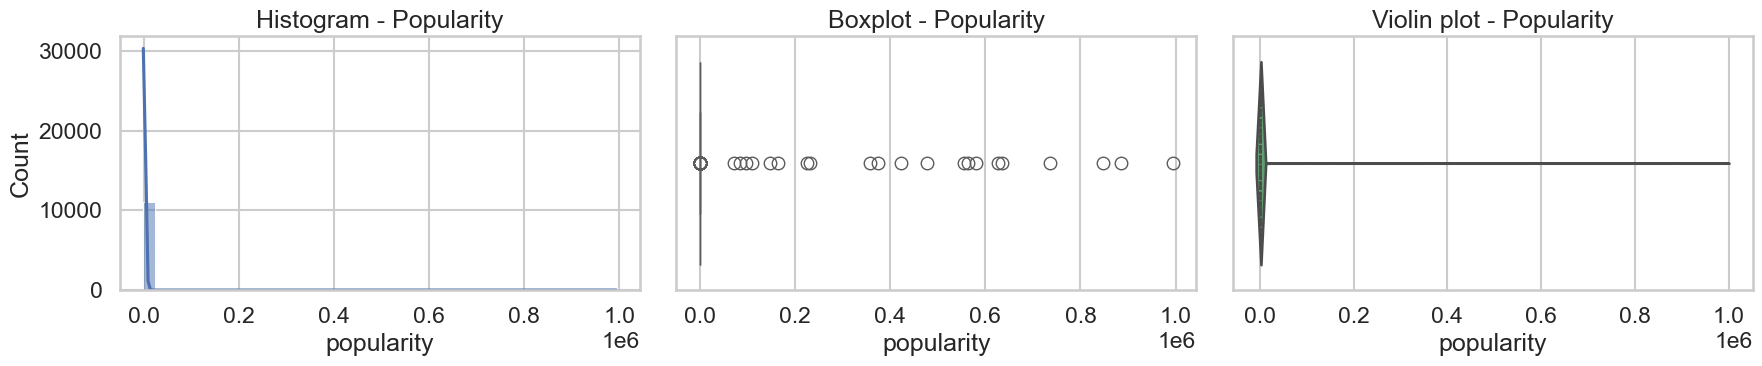

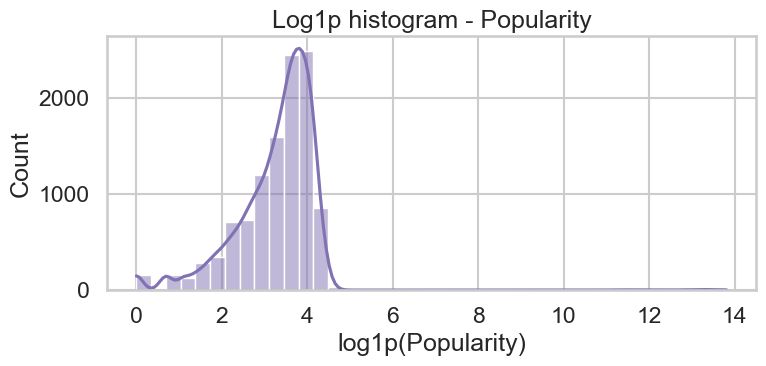

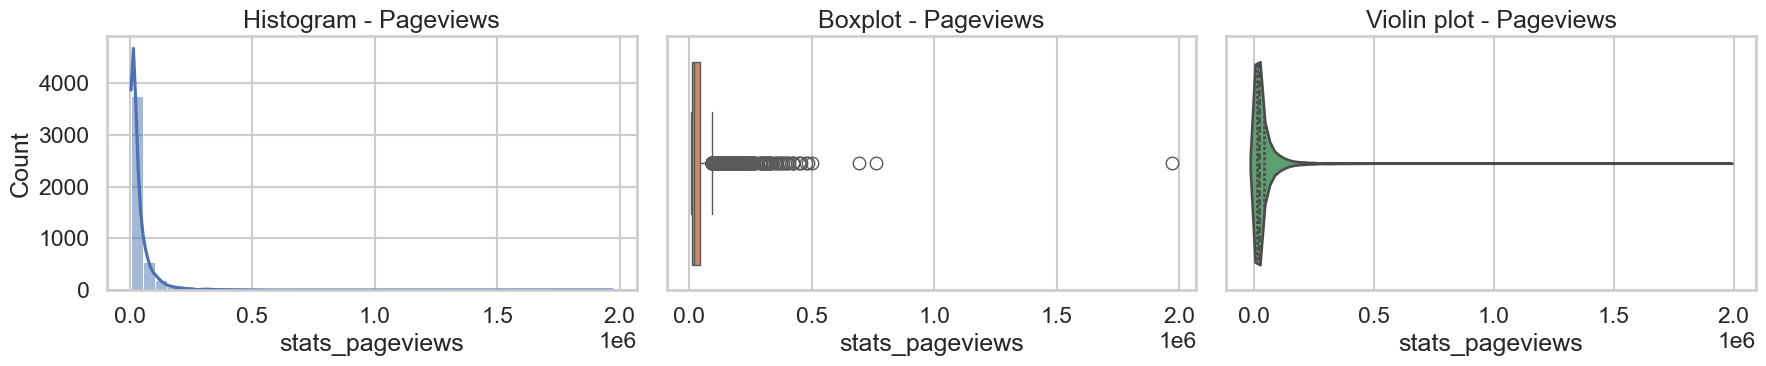

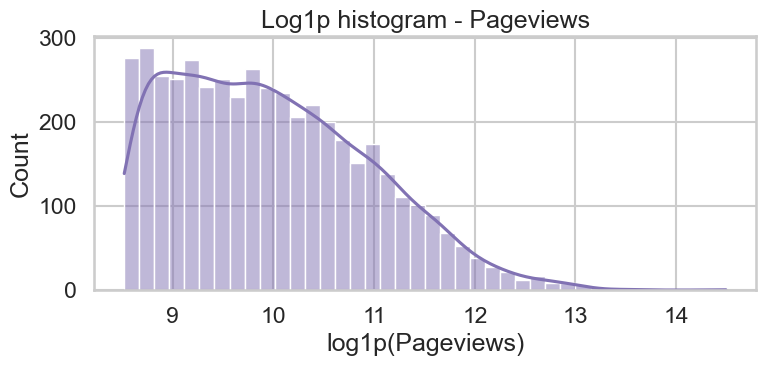

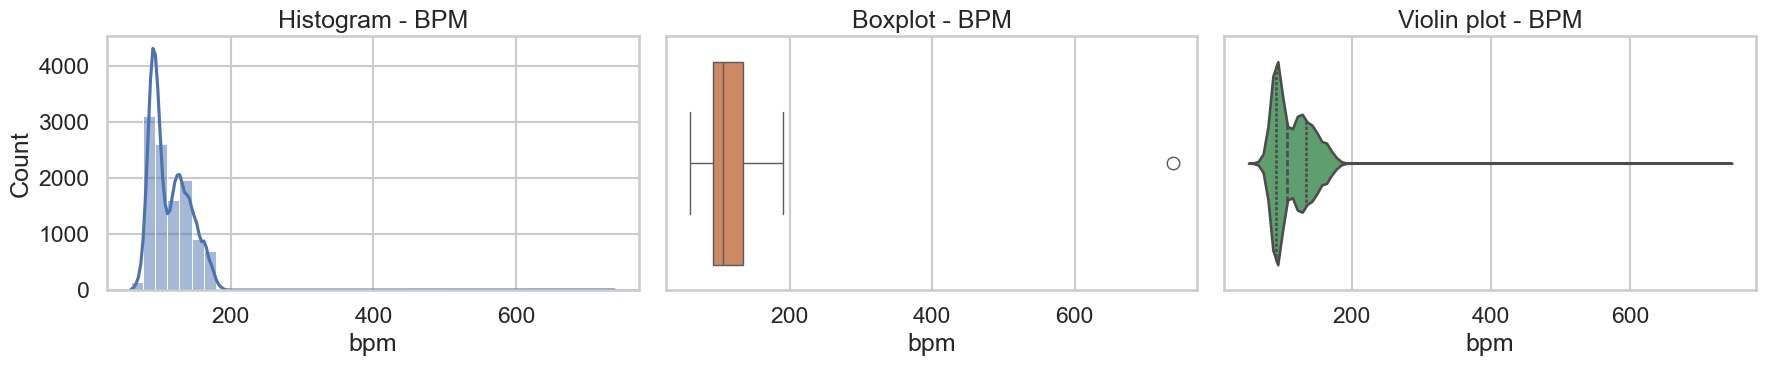

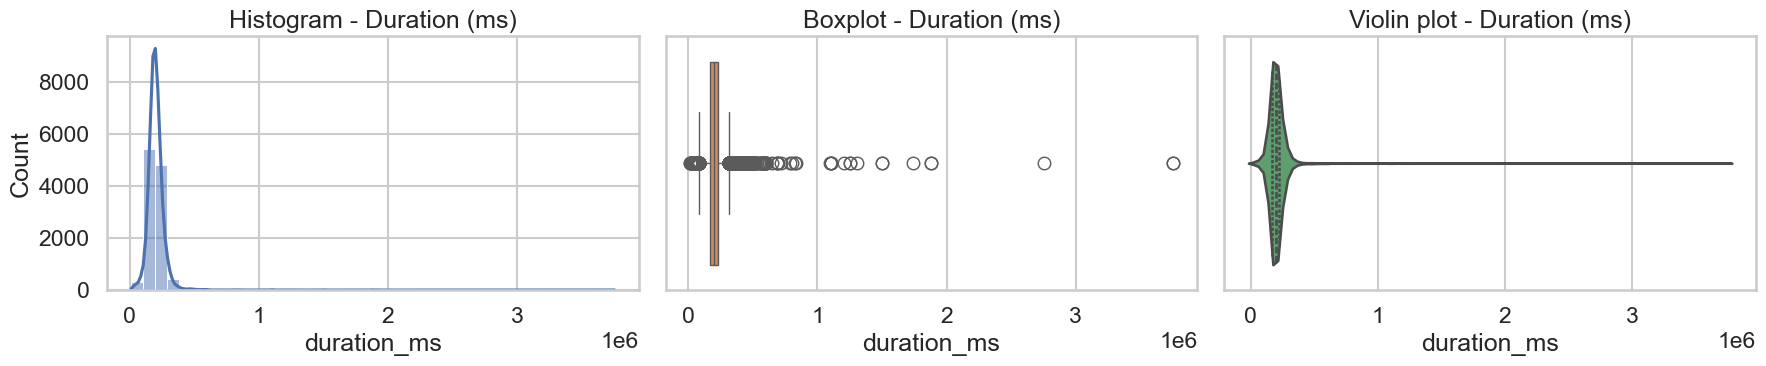

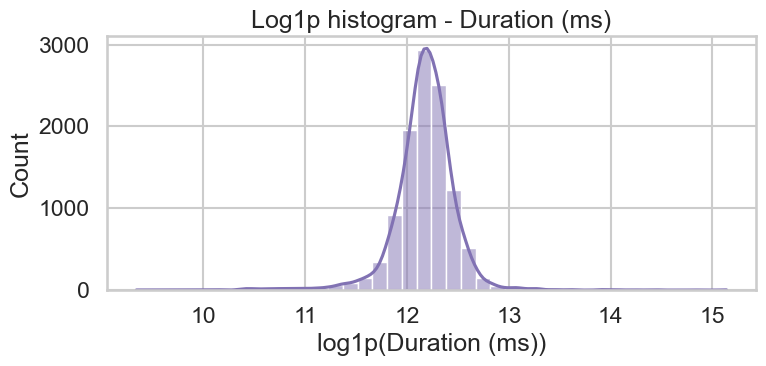

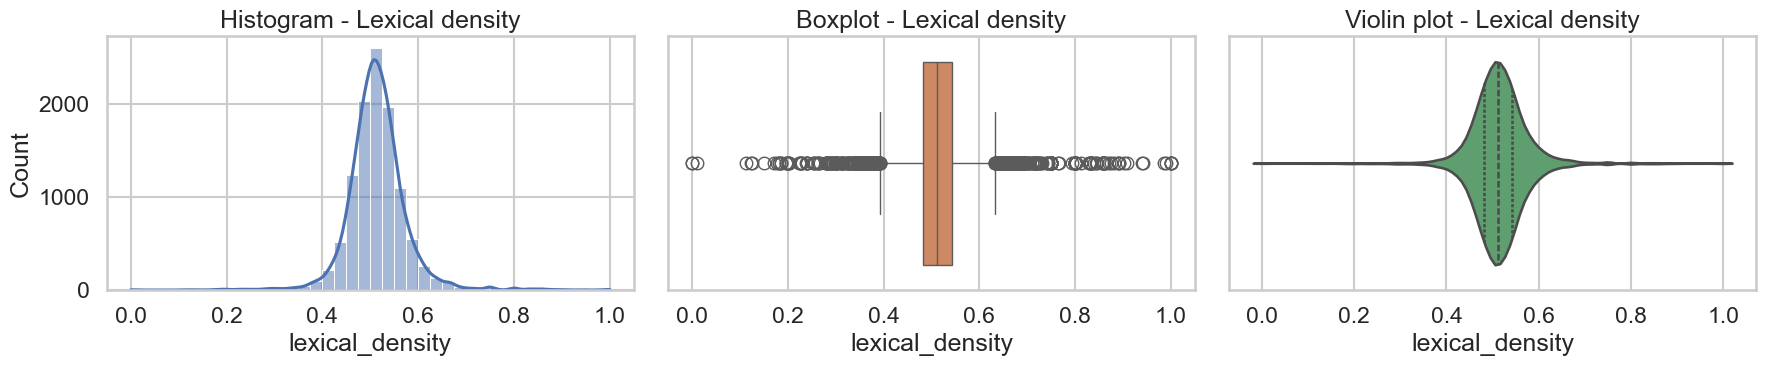

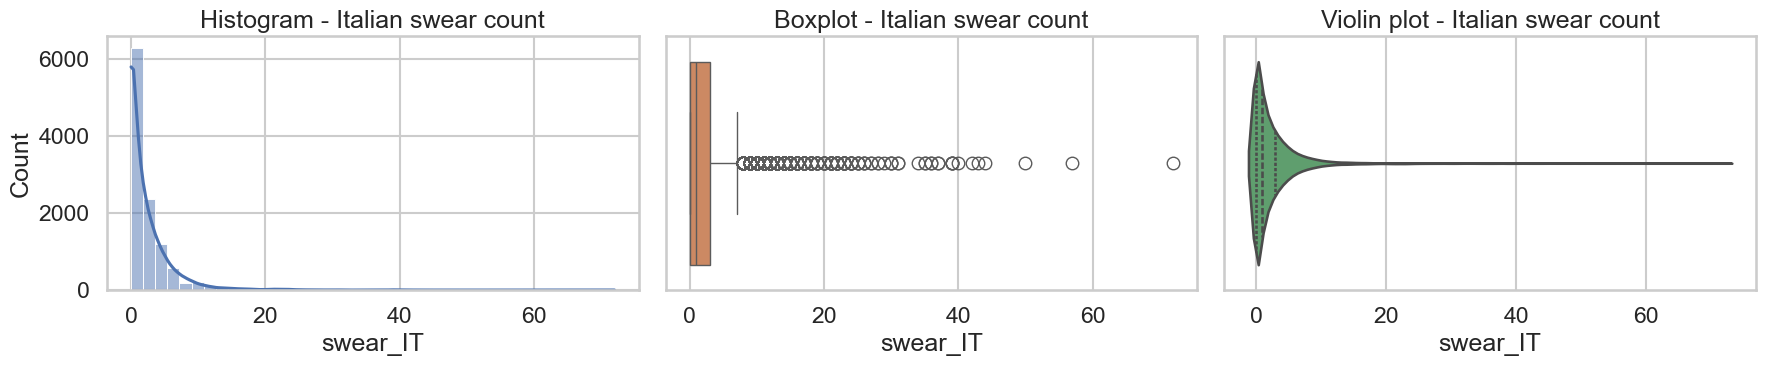

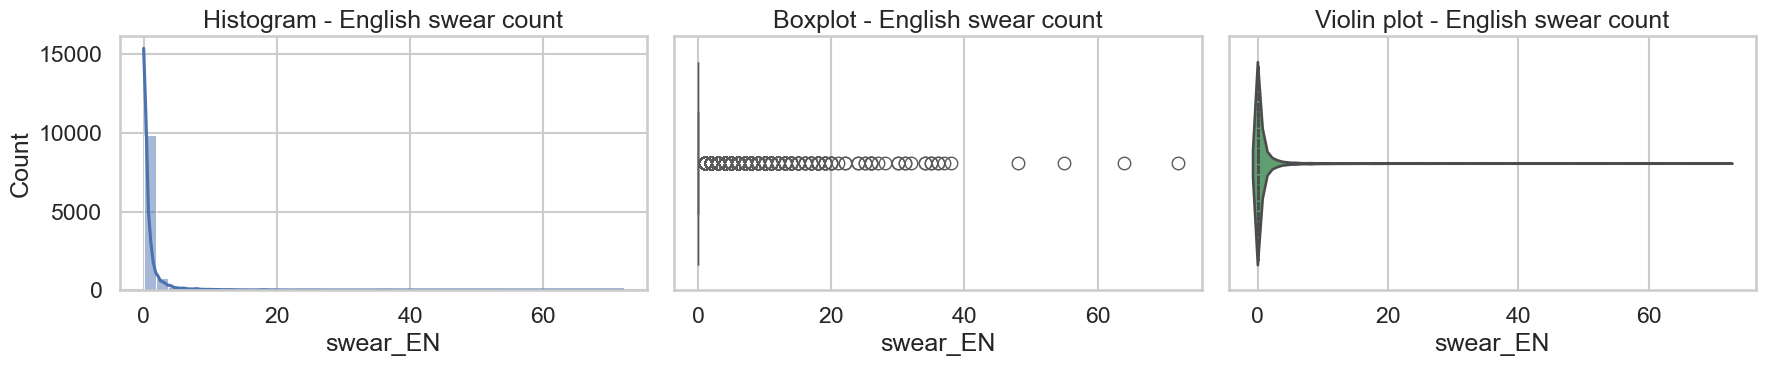

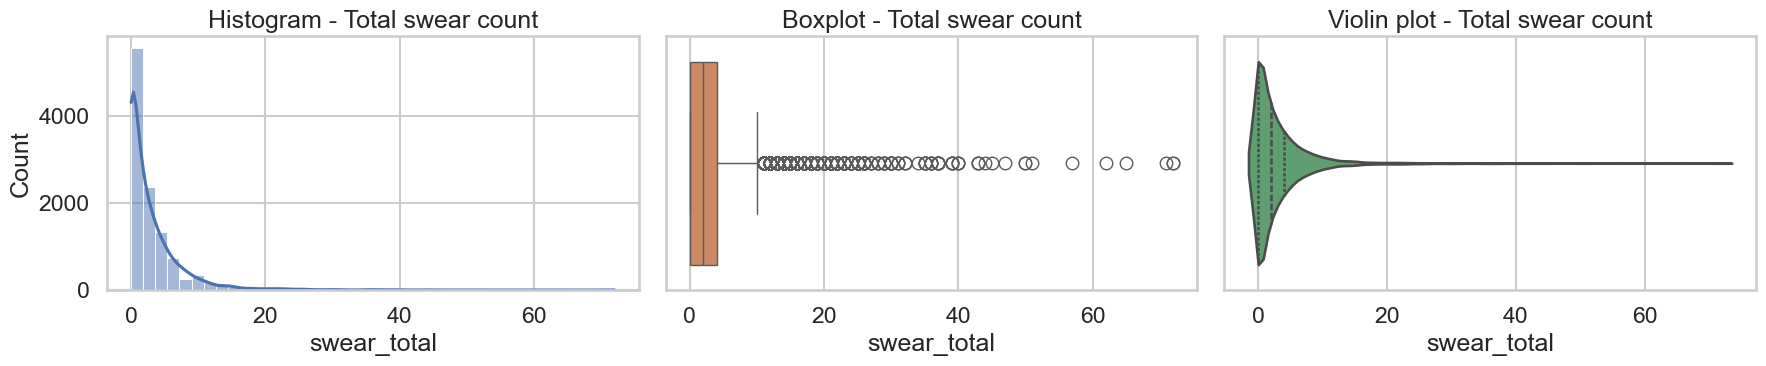

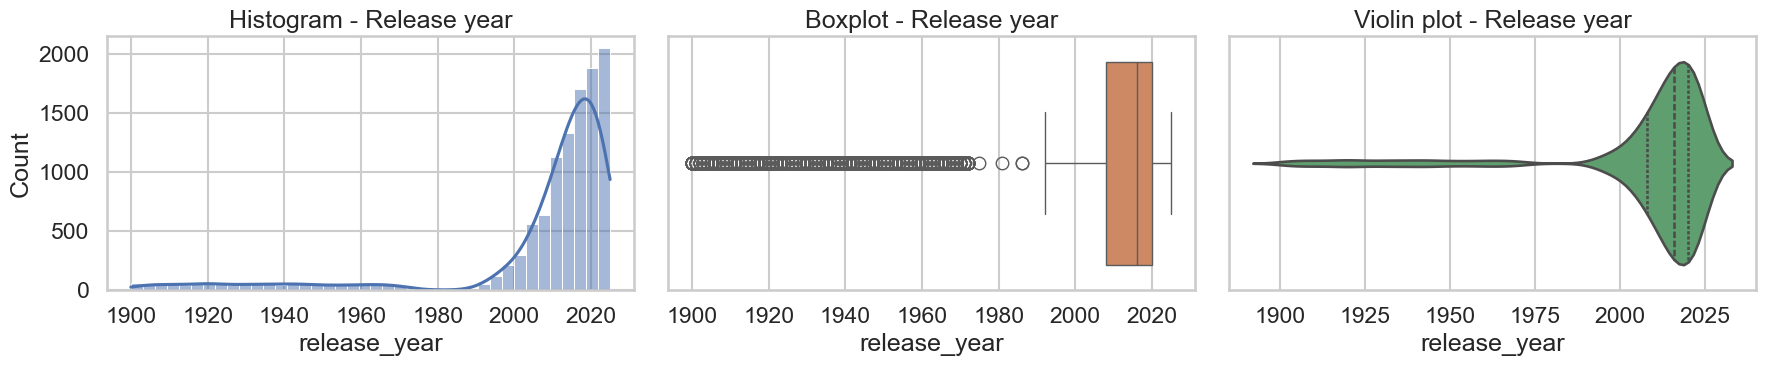

In [86]:
def plot_distribution_triplet(data, column, pretty_name=None, log1p=False):
    series = data[column].dropna()
    if series.empty:
        print(f"Skipping {column}: no valid values.")
        return

    label = pretty_name or column
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(series, bins=40, kde=True, ax=axes[0], color="#4c72b0")
    axes[0].set_title(f"Histogram - {label}")

    sns.boxplot(x=series, ax=axes[1], color="#dd8452")
    axes[1].set_title(f"Boxplot - {label}")

    sns.violinplot(x=series, ax=axes[2], color="#55a868", inner="quartile")
    axes[2].set_title(f"Violin plot - {label}")

    plt.tight_layout()
    plt.show()

    if log1p:
        non_negative = series[series >= 0]
        if not non_negative.empty:
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.histplot(np.log1p(non_negative), bins=40, kde=True, ax=ax, color="#8172b3")
            ax.set_title(f"Log1p histogram - {label}")
            ax.set_xlabel(f"log1p({label})")
            plt.tight_layout()
            plt.show()

variables_to_plot = [
    ("popularity", "Popularity", True),
    ("stats_pageviews", "Pageviews", True),
    ("bpm", "BPM", False),
    ("duration_ms", "Duration (ms)", True),
    ("lexical_density", "Lexical density", False),
    ("swear_IT", "Italian swear count", False),
    ("swear_EN", "English swear count", False),
    ("swear_total", "Total swear count", False),
    ("release_year", "Release year", False),
]

for column, label, use_log in variables_to_plot:
    plot_distribution_triplet(df, column, pretty_name=label, log1p=use_log)


## Swear Density And Regionality

This section connects the custom feature engineering to the project question by comparing profanity density across artist macro-areas and analysing how the geographic origin deviates from the most common origin (north).


,count,mean,median,std
artist_macroarea,,,,
North,4293,0.006735,0.003831,0.009696
Center,1233,0.006654,0.004310,0.008918
South,1715,0.004206,0.001848,0.007042
Islands,707,0.006407,0.004464,0.007404
Missing,3142,0.005681,0.002821,0.009767


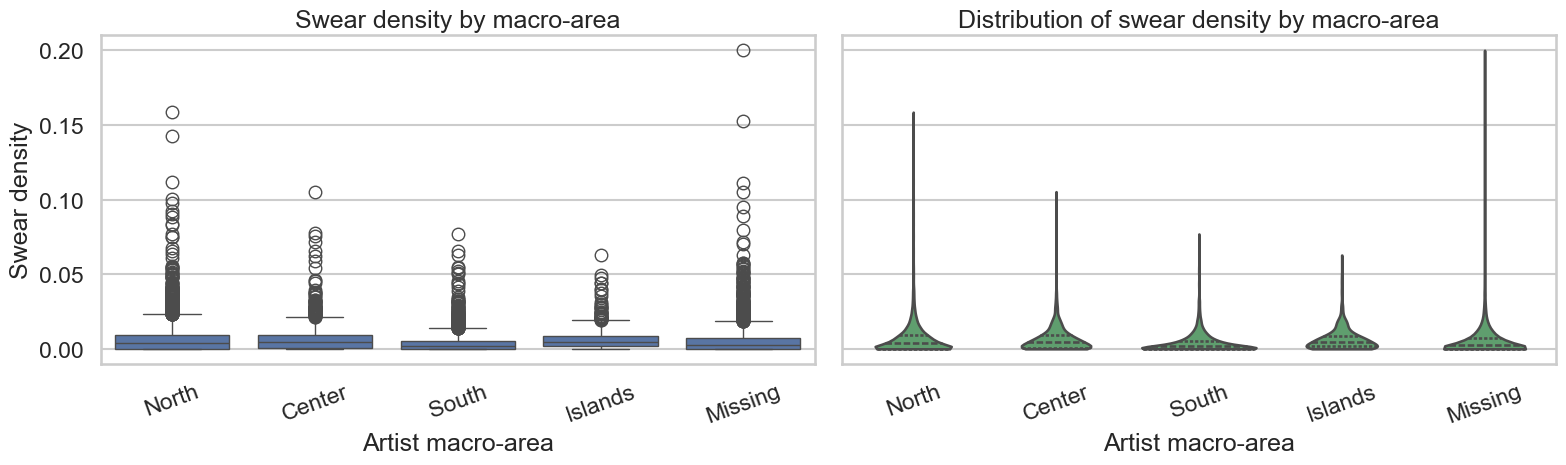

,song_count
artist_macroarea,
North,4368
Center,1233
South,1715
Islands,708
Missing,3142


,count,mean,median,max
artist_macroarea,,,,
North,40,0.314583,0.000000,0.958333
Center,10,0.725000,0.666667,0.958333
South,13,0.663462,0.583333,0.958333
Islands,5,0.858333,0.833333,0.958333
Missing,0,NaN,NaN,NaN


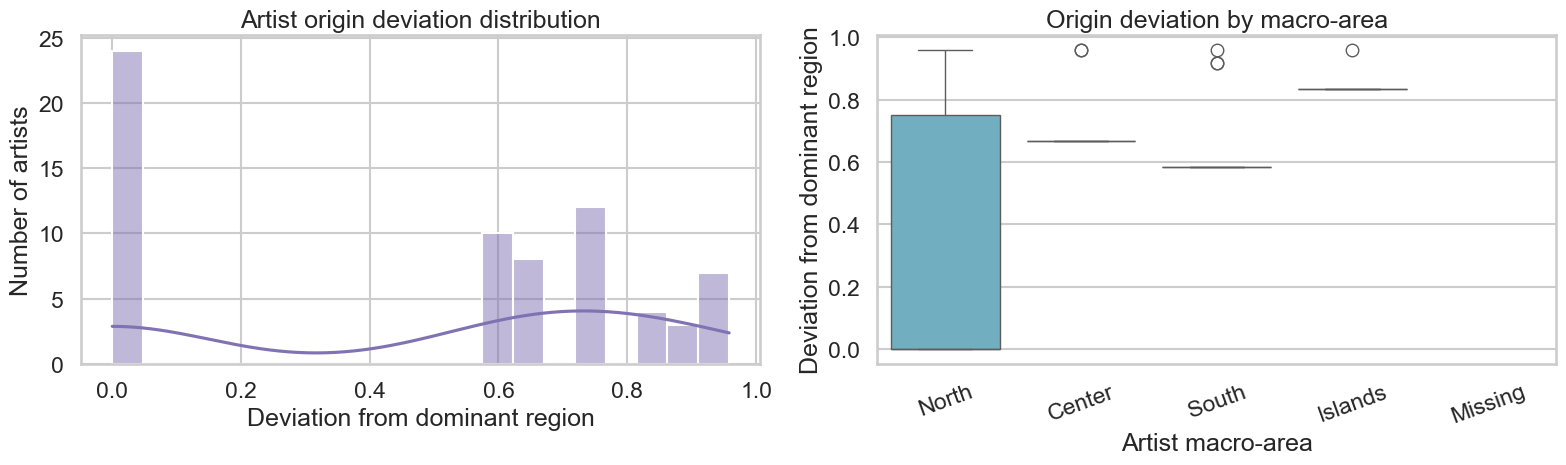

Interpretation note: higher values indicate artists coming from less represented origins, while 0 indicates the dominant origin group.


In [87]:
macroarea_order = ["North", "Center", "South", "Islands", "Missing"]
macroarea_stats = (
    df.groupby("artist_macroarea")["swear_density_total"]
    .agg(["count", "mean", "median", "std"])
    .reindex(macroarea_order)
)

display(macroarea_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.boxplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by macro-area")
axes[0].set_xlabel("Artist macro-area")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=20)

sns.violinplot(
    data=df,
    x="artist_macroarea",
    y="swear_density_total",
    order=macroarea_order,
    ax=axes[1],
    color="#55a868",
    inner="quartile",
    cut=0,
)
axes[1].set_title("Distribution of swear density by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Swear density")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

coverage_by_macroarea = df["artist_macroarea"].value_counts().reindex(macroarea_order)
display(coverage_by_macroarea.rename("song_count").to_frame())

# Geographic deviation representation (artist-level)
artist_geo = (
    df[["id_author", "artist_macroarea", "artist_geographic_diversity"]]
    .drop_duplicates(subset=["id_author"])
)

geo_deviation_summary = (
    artist_geo.groupby("artist_macroarea")["artist_geographic_diversity"]
    .agg(["count", "mean", "median", "max"])
    .reindex(macroarea_order)
)
display(geo_deviation_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(
    artist_geo["artist_geographic_diversity"].dropna(),
    bins=20,
    kde=True,
    ax=axes[0],
    color="#8172b3",
)
axes[0].set_title("Artist origin deviation distribution")
axes[0].set_xlabel("Deviation from dominant region")
axes[0].set_ylabel("Number of artists")

sns.boxplot(
    data=artist_geo,
    x="artist_macroarea",
    y="artist_geographic_diversity",
    order=macroarea_order,
    ax=axes[1],
    color="#64b5cd",
)
axes[1].set_title("Origin deviation by macro-area")
axes[1].set_xlabel("Artist macro-area")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(
    "Interpretation note: higher values indicate artists coming from less represented origins, "
    "while 0 indicates the dominant origin group."
)


,song_count
mood_label,
energetic,1052
cheerful,2133
calm,988
sad,1714
tense,1358
aggressive,774
neutral,3147


,song_count,mean_swear_total,mean_swear_density,median_geo_deviation,mean_geo_deviation
mood_label,,,,,
energetic,1052,4.519962,0.008338,0.666667,0.487821
cheerful,2133,3.488045,0.006898,0.666667,0.501843
calm,988,3.047571,0.006160,0.666667,0.485992
sad,1714,1.875729,0.004201,0.583333,0.473925
tense,1358,3.295287,0.006007,0.666667,0.491481
aggressive,774,2.763566,0.005498,0.583333,0.453547
neutral,3147,2.881474,0.005716,0.666667,0.505408


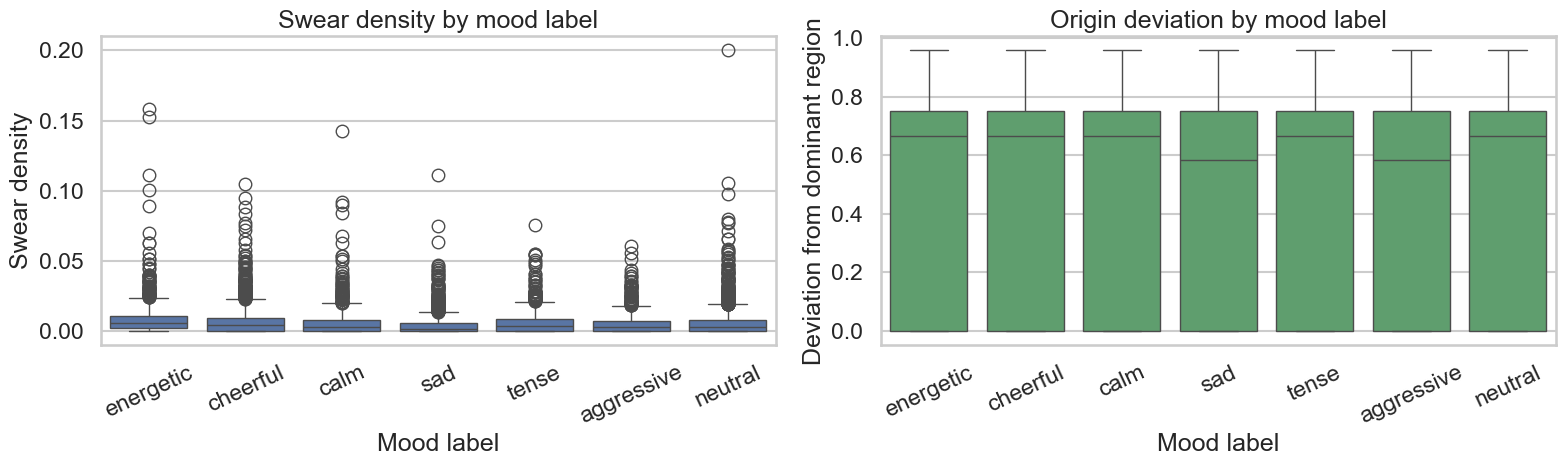

Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Valence is less reliable than arousal with low-level features only.


In [88]:
# Valence–Arousal Mood Labeling (MER-inspired)
# Academic mapping of audio features to 2D mood space with quantile-based thresholds

# 1. Normalize features to [0,1] (min-max)
def minmax_norm(series):
    numeric = pd.to_numeric(series, errors="coerce")
    return (numeric - numeric.min()) / (numeric.max() - numeric.min())

# Features for arousal and valence
arousal_features = ["bpm", "loudness", "rms", "flux", "spectral_complexity"]
valence_features = ["centroid", "rolloff", "pitch", "flatness", "zcr"]

# Normalize all needed features
for col in arousal_features + valence_features:
    df[f"norm_{col}"] = minmax_norm(df[col])

# 2. Compute arousal and valence scores (weighted sum, as per academic guidance)
df["arousal_score"] = (
    0.30 * df["norm_bpm"] +
    0.25 * df["norm_loudness"] +
    0.20 * df["norm_rms"] +
    0.15 * df["norm_flux"] +
    0.10 * df["norm_spectral_complexity"]
)
df["valence_score"] = (
    0.30 * df["norm_centroid"] +
    0.20 * df["norm_rolloff"] +
    0.20 * df["norm_pitch"] +
    0.15 * (1 - df["norm_flatness"]) +
    0.15 * (1 - df["norm_zcr"])
)

# 3. Normalize arousal/valence scores to [0,1] for quantile thresholding
def norm01(series):
    return (series - series.min()) / (series.max() - series.min())
df["arousal_score_n"] = norm01(df["arousal_score"])
df["valence_score_n"] = norm01(df["valence_score"])

# 4. Quantile thresholds (tertiles)
a_hi = df["arousal_score_n"] > df["arousal_score_n"].quantile(0.66)
a_lo = df["arousal_score_n"] < df["arousal_score_n"].quantile(0.33)
v_hi = df["valence_score_n"] > df["valence_score_n"].quantile(0.66)
v_lo = df["valence_score_n"] < df["valence_score_n"].quantile(0.33)

# 5. Assign mood category (6-class system)
def assign_mood(row):
    a = row["arousal_score_n"]
    v = row["valence_score_n"]
    a_hi = a > df["arousal_score_n"].quantile(0.66)
    a_lo = a < df["arousal_score_n"].quantile(0.33)
    v_hi = v > df["valence_score_n"].quantile(0.66)
    v_lo = v < df["valence_score_n"].quantile(0.33)
    if v_hi and a > df["arousal_score_n"].quantile(0.80):
        return "energetic"
    if v_hi and not a_hi:
        return "cheerful"
    if v_lo and a_lo:
        return "sad"
    if v_lo and a_hi:
        return "aggressive"
    if not v_hi and a_hi:
        return "tense"
    if not v_lo and a_lo:
        return "calm"
    return "neutral"
df["mood_label"] = df.apply(assign_mood, axis=1)

# Summary table: mood label counts and mean audio features
mood_order = ["energetic", "cheerful", "calm", "sad", "tense", "aggressive", "neutral"]
mood_counts = df["mood_label"].value_counts().reindex(mood_order).fillna(0).astype(int)
display(mood_counts.rename("song_count").to_frame())

mood_profile = (
    df.groupby("mood_label")
    .agg(
        song_count=("mood_label", "size"),
        mean_swear_total=("swear_total", "mean"),
        mean_swear_density=("swear_density_total", "mean"),
        median_geo_deviation=("artist_geographic_diversity", "median"),
        mean_geo_deviation=("artist_geographic_diversity", "mean"),
    )
    .reindex(mood_order)
)
display(mood_profile)

# Visualization: boxplots for swear density and geo deviation by mood
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(
    data=df,
    x="mood_label",
    y="swear_density_total",
    order=mood_order,
    ax=axes[0],
    color="#4c72b0",
)
axes[0].set_title("Swear density by mood label")
axes[0].set_xlabel("Mood label")
axes[0].set_ylabel("Swear density")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=df,
    x="mood_label",
    y="artist_geographic_diversity",
    order=mood_order,
    ax=axes[1],
    color="#55a868",
)
axes[1].set_title("Origin deviation by mood label")
axes[1].set_xlabel("Mood label")
axes[1].set_ylabel("Deviation from dominant region")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print(
    "Interpretation note: Mood labels are based on a weighted combination of normalized audio features, following academic MER practice. Valence is less reliable than arousal with low-level features only."
)


## Correlation And Redundancy Analysis

We restrict the correlation matrices to cleaned numeric variables, compare Pearson and Spearman correlation, and highlight strongly related pairs.


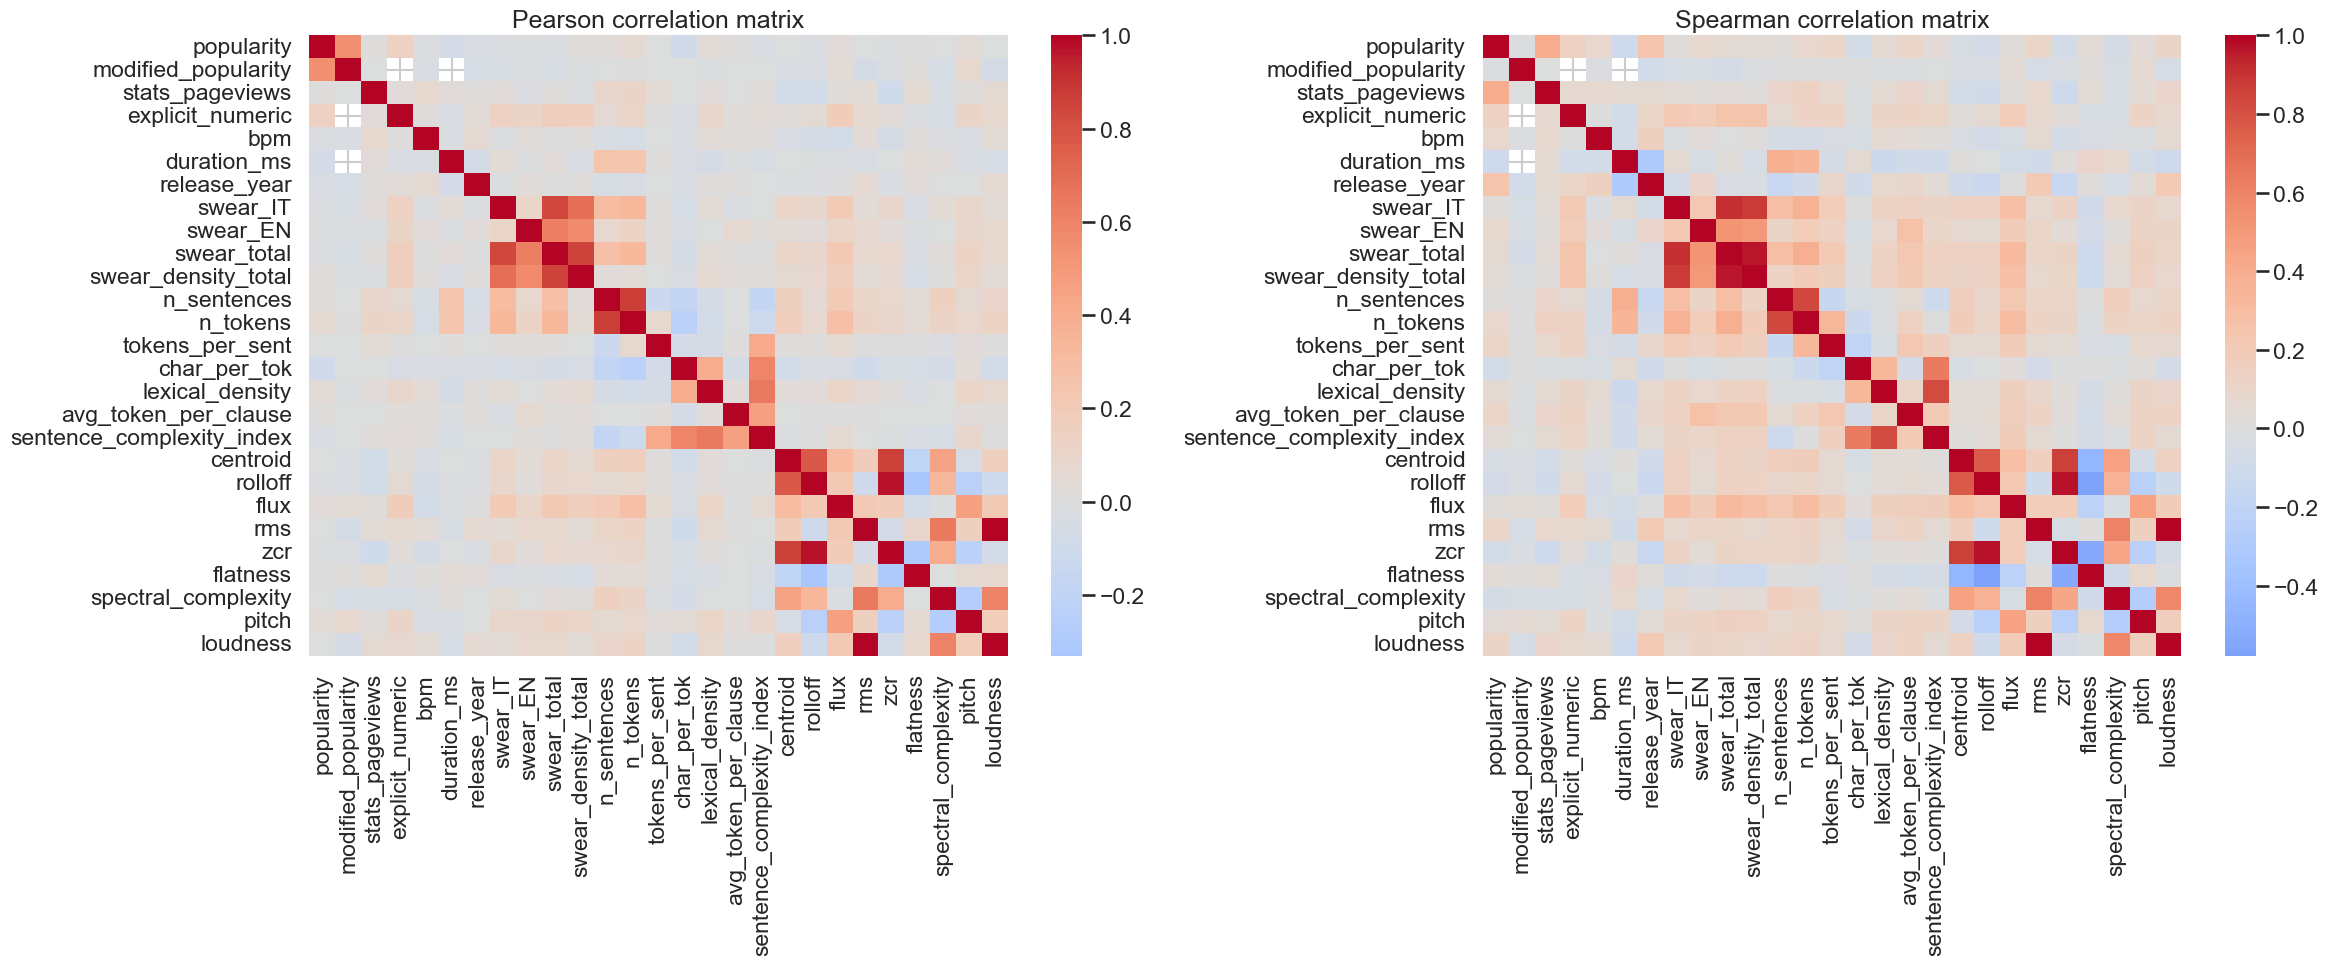

,feature_a,feature_b,correlation
593,rms,loudness,0.995555
535,rolloff,zcr,0.969101
309,n_sentences,n_tokens,0.867722
508,centroid,zcr,0.864465
253,swear_total,swear_density_total,0.850815
198,swear_IT,swear_total,0.842240
505,centroid,rolloff,0.775666


,popularity,stats_pageviews,explicit_numeric,swear_density_total,sentence_complexity_index,bpm,duration_ms,release_year
avg_token_per_clause,0.009127,-0.004244,0.017821,0.030421,0.465024,0.022503,-0.011927,0.009068
bpm,-0.016027,0.073400,0.010930,0.011372,0.012451,1.000000,-0.024087,0.057980
centroid,-0.005341,-0.076413,0.022023,0.064252,-0.021909,-0.034110,0.000728,-0.018405
char_per_tok,-0.091025,-0.004183,-0.031418,-0.038724,0.597111,-0.028625,-0.032533,-0.026621
duration_ms,-0.064938,0.031006,-0.035152,-0.037023,-0.043179,-0.024087,1.000000,-0.068144
explicit_numeric,0.140699,0.028444,1.000000,0.162586,0.038477,0.010930,-0.035152,0.038115
flatness,0.004669,0.051428,-0.021993,-0.054065,-0.032699,0.008762,0.037301,0.025773
flux,0.029226,0.019972,0.175525,0.166526,0.061990,-0.071779,-0.021428,0.005789
lexical_density,0.034742,0.027684,0.090914,0.062765,0.645220,0.035096,-0.057187,0.008615
loudness,-0.003603,0.050282,0.079475,0.048064,0.002904,0.041160,-0.047308,0.064468


In [89]:
correlation_columns = [
    "popularity",
    "modified_popularity",
    "stats_pageviews",
    "explicit_numeric",
    "bpm",
    "duration_ms",
    "release_year",
    "swear_IT",
    "swear_EN",
    "swear_total",
    "swear_density_total",
    "n_sentences",
    "n_tokens",
    "tokens_per_sent",
    "char_per_tok",
    "lexical_density",
    "avg_token_per_clause",
    "sentence_complexity_index",
    "centroid",
    "rolloff",
    "flux",
    "rms",
    "zcr",
    "flatness",
    "spectral_complexity",
    "pitch",
    "loudness",
]

corr_df = df[correlation_columns].copy()
pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation matrix")

sns.heatmap(spearman_corr, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation matrix")

plt.tight_layout()
plt.show()

def top_correlation_pairs(corr_matrix, threshold=0.7):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    return pairs.loc[pairs["correlation"].abs() >= threshold].sort_values(
        "correlation",
        key=lambda s: s.abs(),
        ascending=False,
    )

high_corr_pairs = top_correlation_pairs(pearson_corr, threshold=0.7)
focus_features = [
    "popularity",
    "stats_pageviews",
    "explicit_numeric",
    "swear_density_total",
    "sentence_complexity_index",
    "bpm",
    "duration_ms",
    "release_year",
]

focus_corr = pearson_corr.loc[focus_features, corr_df.columns].T.sort_index()

display(high_corr_pairs)
display(focus_corr)


After Correlation Analysis, we identify redundant features and select a subset of non-redundant features for later modeling.

In [90]:
# Correlation-aware feature subset selection (points 1-4 of the strategy)

# 1) Build redundancy groups from Pearson correlation

# 2) Score features with a documented keep-score function

# 3) Keep one anchor per group

# 4) Keep a second feature only when it adds distinct signal



candidate_features = [c for c in correlation_columns if c in df.columns]

target_col = "target_macroarea_code" if "target_macroarea_code" in df.columns else None



# Build semantic groups from known feature families

semantic_group_map = {}

for group_name, cols in uf.FEATURE_GROUPS.items():

    for col in cols:

        semantic_group_map[col] = group_name



# Add engineered features if documented in engineered_docs

if "engineered_docs" in locals() and {"feature", "family"}.issubset(engineered_docs.columns):

    for _, row in engineered_docs[["feature", "family"]].dropna().iterrows():

        semantic_group_map[str(row["feature"])] = str(row["family"])



corr_matrix, redundancy_groups = uf.build_correlation_groups(

    df=df,

    feature_columns=candidate_features,

    method="pearson",

    corr_threshold=0.85,

    min_periods=30,

)



feature_scores = uf.compute_feature_keep_scores(

    df=df,

    feature_columns=candidate_features,

    target_column=target_col,

    semantic_group_map=semantic_group_map,

)



selected_score_table, selection_decisions, selected_features_for_modeling = uf.select_redundant_features(

    corr_matrix=corr_matrix,

    redundancy_groups=redundancy_groups,

    score_table=feature_scores,

    semantic_group_map=semantic_group_map,

    target_corr_delta=0.05,

    hard_drop_threshold=0.95,

    max_keep_per_group=2,

)



# ---------- Human-readable reporting ----------

score_cols = [

    "feature",

    "semantic_group",

    "keep_score",

    "target_relevance",

    "low_missingness",

    "stability",

]

decision_view = selection_decisions.merge(feature_scores[score_cols], on="feature", how="left")



decision_order = {"keep_anchor": 0, "keep_secondary": 1, "drop": 2}

decision_view["decision_order"] = decision_view["decision"].map(decision_order).fillna(9)

decision_view = decision_view.sort_values(["group_id", "decision_order", "keep_score"], ascending=[True, True, False])



for col in ["keep_score", "target_relevance", "low_missingness", "stability"]:

    decision_view[col] = decision_view[col].round(3)



summary_table = pd.DataFrame(

    {

        "metric": [

            "candidate_features",

            "correlation_groups",

            "anchors_kept",

            "secondary_kept",

            "features_dropped_in_groups",

            "selected_features_from_groups",

        ],

        "value": [

            len(candidate_features),

            len(redundancy_groups),

            int((decision_view["decision"] == "keep_anchor").sum()),

            int((decision_view["decision"] == "keep_secondary").sum()),

            int((decision_view["decision"] == "drop").sum()),

            len(selected_features_for_modeling),

        ],

    }

)

def _max_abs_corr_in_group(group_features):

    if len(group_features) < 2:

        return np.nan

    sub = corr_matrix.loc[group_features, group_features].abs()
    
    upper = sub.where(np.triu(np.ones(sub.shape), k=1).astype(bool))

    values = upper.stack()

    return np.nan if values.empty else float(values.max())



group_rows = []

for idx, group_features in enumerate(redundancy_groups, start=1):

    group_dec = decision_view[decision_view["group_id"] == idx]

    anchor = group_dec.loc[group_dec["decision"] == "keep_anchor", "feature"]

    secondaries = group_dec.loc[group_dec["decision"] == "keep_secondary", "feature"].tolist()

    dropped = group_dec.loc[group_dec["decision"] == "drop", "feature"].tolist()

    group_rows.append(

        {

            "group_id": idx,

            "group_size": len(group_features),

            "max_abs_corr": round(_max_abs_corr_in_group(group_features), 3),

            "anchor": anchor.iloc[0] if not anchor.empty else "",

            "kept_secondary": ", ".join(secondaries) if secondaries else "-",

            "dropped": ", ".join(dropped) if dropped else "-",

        }

    )



group_overview = pd.DataFrame(group_rows)



selected_details = (

    decision_view[decision_view["decision"].isin(["keep_anchor", "keep_secondary"])]

    .sort_values(["keep_score", "decision_order"], ascending=[False, True])

    [["group_id", "feature", "decision", "semantic_group", "keep_score", "reason"]]

    .rename(columns={"decision": "selection_role", "reason": "why_kept"})

    .reset_index(drop=True)

)



dropped_details = (

    decision_view[decision_view["decision"] == "drop"]

    .sort_values(["group_id", "keep_score"], ascending=[True, False])

    [["group_id", "feature", "semantic_group", "keep_score", "reason"]]

    .rename(columns={"reason": "why_dropped"})

    .reset_index(drop=True)

)



print("Feature-selection summary (correlation-aware, points 1-4)")

display(summary_table)



print("Group-level decisions")

display(group_overview)



print("Kept features (for next analysis step)")

display(selected_details)



if not dropped_details.empty:

    print("Dropped features inside correlated groups")

    display(dropped_details)



if target_col is None:

    print("Note: target_relevance is 0 because no numeric target column is currently available.")


Feature-selection summary (correlation-aware, points 1-4)


,metric,value
0,candidate_features,27
1,correlation_groups,4
2,anchors_kept,4
3,secondary_kept,3
4,features_dropped_in_groups,2
5,selected_features_from_groups,7


Group-level decisions


,group_id,group_size,max_abs_corr,anchor,kept_secondary,dropped
0,1,3,0.969,centroid,zcr,rolloff
1,2,2,0.996,rms,-,loudness
2,3,2,0.868,n_sentences,n_tokens,-
3,4,2,0.851,swear_total,swear_density_total,-


Kept features (for next analysis step)


,group_id,feature,selection_role,semantic_group,keep_score,why_kept
0,1,centroid,keep_anchor,audio,0.408,highest_keep_score_in_group
1,1,zcr,keep_secondary,audio,0.392,corr_below_hard_drop
2,2,rms,keep_anchor,audio,0.391,highest_keep_score_in_group
3,3,n_sentences,keep_anchor,textual,0.365,highest_keep_score_in_group
4,3,n_tokens,keep_secondary,textual,0.364,corr_below_hard_drop
5,4,swear_total,keep_anchor,unknown,0.250,highest_keep_score_in_group
6,4,swear_density_total,keep_secondary,unknown,0.249,corr_below_hard_drop


Dropped features inside correlated groups


,group_id,feature,semantic_group,keep_score,why_dropped
0,1,rolloff,audio,0.379,max_keep_per_group_reached
1,2,loudness,audio,0.377,high_correlation_without_distinct_signal


Note: target_relevance is 0 because no numeric target column is currently available.


# Task 2 - Pattern Mining for Feature Discovery

## Objective
Apply association rule mining to discover interpretable patterns in the Italian rap songs dataset and transform high-value rules into binary features for downstream modeling.

## Update note
The legacy fixed-threshold discretization and legacy rule-metric cells have been replaced.
The canonical implementation is now:
1. Task 2.1: dataset-aware cleaning + discretization
2. Task 2.2: visual validation of discretized bins
3. Task 2.3: Apriori frequent itemsets + association rules
4. Task 2.4: exact rule metric retrieval and rule-based feature engineering

## Task 2 Implementation Plan

### Phase 1: Discretization Strategy
Transform continuous features into categorical bins with clear interpretation, using dataset-aware thresholds where appropriate.

**Variables discretized:**
- bpm (empirical tertiles after OOD cleaning)
- popularity (empirical tertiles after enforcing [0, 100])
- stats_pageviews (empirical tertiles on $log(1p)$ to better represent the skewed distribution)
- swear_density_total (NoSwear / LowSwear / HighSwear)
- sentence_complexity_index (empirical tertiles)
- duration_ms (empirical tertiles after plausibility filtering)
- explicit (Yes/No)
- release_period (Classic / Mid / Recent from cleaned release year accepted from 1970 - today's date)
- artist_macroarea (categorical)
- mood_label (categorical)
- language_group (Italian / English / Other)

### Phase 2: Transaction Encoding
Create a transactional matrix where each song is one transaction and each category level is one item.

### Phase 3: Apriori Setup
Mine frequent itemsets and generate rules with support, confidence, lift, leverage, and conviction.

### Phase 4: Rule Selection and Feature Engineering
Select high-value rules and convert their antecedents into binary engineered features; attach exact rule metrics from the mined rules table.

## Expected Deliverables
- Discretization and cleaning summary
- Frequent itemsets and association rules
- Rule-based binary features added to df
- Rule interpretation table with support/confidence/lift

In [91]:
# Task 2.1 — Dataset-aware cleaning and discretization for Apriori

apriori_df = df.copy()
current_year = pd.Timestamp.today().year

# --- Clean variables only for Apriori mining ---
# Keep the original df unchanged, but avoid mining rules driven by corrupted values.
apriori_df["ap_popularity"] = apriori_df["popularity"].where(
    apriori_df["popularity"].between(0, 100)
)

apriori_df["ap_bpm"] = apriori_df["bpm"].where(
    apriori_df["bpm"].between(40, 250)
)

apriori_df["ap_duration_seconds"] = (apriori_df["duration_ms"] / 1000.0).where(
    apriori_df["duration_ms"].between(30_000, 900_000)
)

# Prefer the track release year when plausible, otherwise fallback to album_release_date.
raw_release_year = pd.to_numeric(apriori_df["release_year"], errors="coerce")
album_year = pd.to_datetime(apriori_df["album_release_date"], errors="coerce").dt.year
valid_track_year = raw_release_year.where(raw_release_year.between(1970, current_year))
valid_album_year = album_year.where(album_year.between(1970, current_year))
apriori_df["ap_release_year"] = valid_track_year.fillna(valid_album_year)


def make_tertile_bins(series, labels):
    """Return empirical-tertile bins plus the two thresholds used."""
    numeric = pd.to_numeric(series, errors="coerce")
    q1, q2 = numeric.dropna().quantile([1 / 3, 2 / 3]).to_numpy()
    binned = pd.cut(
        numeric,
        bins=[-np.inf, q1, q2, np.inf],
        labels=labels,
        include_lowest=True,
    )
    return binned, float(q1), float(q2)


# BPM: empirical slow / medium / fast.
apriori_df["disc_bpm"], bpm_q1, bpm_q2 = make_tertile_bins(
    apriori_df["ap_bpm"],
    labels=["Slow", "Medium", "Fast"],
)

# Popularity: empirical low / medium / high after removing impossible values.
apriori_df["disc_popularity"], popularity_q1, popularity_q2 = make_tertile_bins(
    apriori_df["ap_popularity"],
    labels=["Low", "Medium", "High"],
)

# Pageviews: empirical tertiles on log1p because the distribution is very skewed.
apriori_df["disc_pageviews"], pageviews_log_q1, pageviews_log_q2 = make_tertile_bins(
    np.log1p(apriori_df["stats_pageviews"]),
    labels=["LowViews", "MediumViews", "HighViews"],
)
pageviews_q1 = float(np.expm1(pageviews_log_q1)) # Retrieve flat bins inverting the distribution transformation
pageviews_q2 = float(np.expm1(pageviews_log_q2))

# Duration: empirical short / medium / long after filtering implausible durations.
apriori_df["disc_duration"], duration_q1, duration_q2 = make_tertile_bins(
    apriori_df["ap_duration_seconds"],
    labels=["Short", "Medium", "Long"],
)

# Swear density: zero vs positive, with high profanity as the upper quartile among positive values.
positive_swear_density = apriori_df.loc[
    apriori_df["swear_density_total"].gt(0),
    "swear_density_total",
]
high_swear_threshold = float(positive_swear_density.quantile(0.75)) # Define the treshold for high profanity

# Discretize swear density into NoSwear, LowSwear, HighSwear based on the defined thresholds.

apriori_df["disc_swear_density_total"] = pd.Series(
    np.nan,
    index=apriori_df.index,
    dtype="object",
)
# Define the bins based on the thresholds and assign the corresponding labels.
apriori_df.loc[
    apriori_df["swear_density_total"].eq(0),
    "disc_swear_density_total",
] = "NoSwear"
apriori_df.loc[
    apriori_df["swear_density_total"].gt(0)
    & apriori_df["swear_density_total"].lt(high_swear_threshold),
    "disc_swear_density_total",
] = "LowSwear"
apriori_df.loc[
    apriori_df["swear_density_total"].ge(high_swear_threshold),
    "disc_swear_density_total",
] = "HighSwear"

# Sentence complexity: empirical simple / moderate / complex.
apriori_df[
    "disc_sentence_complexity"
], sentence_complexity_q1, sentence_complexity_q2 = make_tertile_bins(
    apriori_df["sentence_complexity_index"],
    labels=["Simple", "Moderate", "Complex"],
)

# Release period: interpretable historical bins, using the cleaned release year.
apriori_df["disc_release_period"] = pd.cut(
    apriori_df["ap_release_year"],
    bins=[-np.inf, 2010, 2020, np.inf],
    labels=["Classic", "Mid", "Recent"],
    right=False,
)

# Binary/categorical variables.
apriori_df["disc_explicit"] = apriori_df["explicit"].map({True: "Yes", False: "No"})
apriori_df["disc_artist_macroarea"] = apriori_df["artist_macroarea"].replace(
    {"Missing": pd.NA}
)
apriori_df["disc_mood_label"] = apriori_df["mood_label"].astype("string")

language_norm = apriori_df["language"].astype("string").str.lower()
apriori_df["disc_language_group"] = "Other"
apriori_df.loc[language_norm.eq("it").fillna(False), "disc_language_group"] = "Italian"
apriori_df.loc[language_norm.eq("en").fillna(False), "disc_language_group"] = "English"
apriori_df.loc[language_norm.isna(), "disc_language_group"] = np.nan

discretized_columns = [
    "disc_bpm",
    "disc_popularity",
    "disc_pageviews",
    "disc_swear_density_total",
    "disc_duration",
    "disc_explicit",
    "disc_release_period",
    "disc_sentence_complexity",
    "disc_artist_macroarea",
    "disc_mood_label",
    "disc_language_group",
]

cleaning_summary = pd.DataFrame(
    [
        {
            "variable": "popularity",
            "valid_rule": "0 <= popularity <= 100",
            "invalid_non_missing_set_to_nan": int(
                apriori_df["popularity"].notna().sum()
                - apriori_df["ap_popularity"].notna().sum()
            ),
            "usable_count": int(apriori_df["ap_popularity"].notna().sum()),
        },
        {
            "variable": "bpm",
            "valid_rule": "40 <= bpm <= 250",
            "invalid_non_missing_set_to_nan": int(
                apriori_df["bpm"].notna().sum() - apriori_df["ap_bpm"].notna().sum()
            ),
            "usable_count": int(apriori_df["ap_bpm"].notna().sum()),
        },
        {
            "variable": "duration_ms",
            "valid_rule": "30s <= duration <= 900s",
            "invalid_non_missing_set_to_nan": int(
                apriori_df["duration_ms"].notna().sum()
                - apriori_df["ap_duration_seconds"].notna().sum()
            ),
            "usable_count": int(apriori_df["ap_duration_seconds"].notna().sum()),
        },
        {
            "variable": "release_year",
            "valid_rule": f"1970 <= year <= {current_year}; fallback to album date",
            "invalid_non_missing_set_to_nan": int(
                raw_release_year.notna().sum() - valid_track_year.notna().sum()
            ),
            "usable_count": int(apriori_df["ap_release_year"].notna().sum()),
        },
    ]
)

discretization_summary = pd.DataFrame(
    [
        {
            "source_feature": "bpm",
            "transaction_feature": "bpm",
            "strategy": "empirical tertiles after OOD cleaning",
            "bins": f"Slow <= {bpm_q1:.2f}; Medium <= {bpm_q2:.2f}; Fast > {bpm_q2:.2f}",
        },
        {
            "source_feature": "popularity",
            "transaction_feature": "popularity",
            "strategy": "empirical tertiles after enforcing 0-100 range",
            "bins": f"Low <= {popularity_q1:.0f}; Medium <= {popularity_q2:.0f}; High > {popularity_q2:.0f}",
        },
        {
            "source_feature": "stats_pageviews",
            "transaction_feature": "pageviews",
            "strategy": "empirical tertiles on log1p(pageviews)",
            "bins": f"LowViews <= {pageviews_q1:.0f}; MediumViews <= {pageviews_q2:.0f}; HighViews > {pageviews_q2:.0f}",
        },
        {
            "source_feature": "duration_ms",
            "transaction_feature": "duration",
            "strategy": "empirical tertiles after filtering implausible durations",
            "bins": f"Short <= {duration_q1:.1f}s; Medium <= {duration_q2:.1f}s; Long > {duration_q2:.1f}s",
        },
        {
            "source_feature": "swear_density_total",
            "transaction_feature": "swear_density_total",
            "strategy": "zero vs positive; high = upper quartile among positive densities",
            "bins": f"NoSwear = 0; LowSwear < {high_swear_threshold:.4f}; HighSwear >= {high_swear_threshold:.4f}",
        },
        {
            "source_feature": "sentence_complexity_index",
            "transaction_feature": "sentence_complexity",
            "strategy": "empirical tertiles",
            "bins": f"Simple <= {sentence_complexity_q1:.3f}; Moderate <= {sentence_complexity_q2:.3f}; Complex > {sentence_complexity_q2:.3f}",
        },
        {
            "source_feature": "ap_release_year",
            "transaction_feature": "release_period",
            "strategy": "interpretable historical bins",
            "bins": "Classic < 2010; Mid 2010-2019; Recent >= 2020",
        },
        {
            "source_feature": "explicit",
            "transaction_feature": "explicit",
            "strategy": "binary categorical",
            "bins": "No / Yes",
        },
        {
            "source_feature": "artist_macroarea",
            "transaction_feature": "artist_macroarea",
            "strategy": "categorical; missing origin is not mined as an item",
            "bins": "North / Center / South / Islands",
        },
        {
            "source_feature": "mood_label",
            "transaction_feature": "mood_label",
            "strategy": "categorical feature engineered in Task 1",
            "bins": "energetic / cheerful / calm / sad / tense / aggressive / neutral",
        },
        {
            "source_feature": "language",
            "transaction_feature": "language_group",
            "strategy": "collapsed categorical",
            "bins": "Italian / English / Other",
        },
    ]
)

bin_count_rows = []
for col in discretized_columns:
    counts = apriori_df[col].value_counts(dropna=False)
    for category, count in counts.items():
        category_label = "Missing" if pd.isna(category) else str(category)
        bin_count_rows.append(
            {
                "discretized_column": col,
                "category": category_label,
                "count": int(count),
                "percentage": round(100 * count / len(apriori_df), 2),
            }
        )

bin_count_table = pd.DataFrame(bin_count_rows)

display(cleaning_summary)
display(discretization_summary)
display(bin_count_table)


,variable,valid_rule,invalid_non_missing_set_to_nan,usable_count
0,popularity,0 <= popularity <= 100,49,11088
1,bpm,40 <= bpm <= 250,1,11101
2,duration_ms,30s <= duration <= 900s,27,11061
3,release_year,1970 <= year <= 2026; fallback to album date,1074,11062


,source_feature,transaction_feature,strategy,bins
0,bpm,bpm,empirical tertiles after OOD cleaning,Slow <= 95.03; Medium <= 126.02; Fast > 126.02
1,popularity,popularity,empirical tertiles after enforcing 0-100 range,Low <= 22; Medium <= 42; High > 42
2,stats_pageviews,pageviews,empirical tertiles on log1p(pageviews),LowViews <= 12032; MediumViews <= 31500; HighV...
3,duration_ms,duration,empirical tertiles after filtering implausible...,Short <= 180.0s; Medium <= 216.0s; Long > 216.0s
4,swear_density_total,swear_density_total,zero vs positive; high = upper quartile among ...,NoSwear = 0; LowSwear < 0.0109; HighSwear >= 0...
5,sentence_complexity_index,sentence_complexity,empirical tertiles,Simple <= -0.158; Moderate <= 0.065; Complex >...
6,ap_release_year,release_period,interpretable historical bins,Classic < 2010; Mid 2010-2019; Recent >= 2020
7,explicit,explicit,binary categorical,No / Yes
8,artist_macroarea,artist_macroarea,categorical; missing origin is not mined as an...,North / Center / South / Islands
9,mood_label,mood_label,categorical feature engineered in Task 1,energetic / cheerful / calm / sad / tense / ag...


,discretized_column,category,count,percentage
0,disc_bpm,Slow,3706,33.19
1,disc_bpm,Fast,3699,33.13
2,disc_bpm,Medium,3696,33.10
3,disc_bpm,Missing,65,0.58
4,disc_popularity,Low,3870,34.66
5,disc_popularity,Medium,3688,33.03
6,disc_popularity,High,3530,31.61
7,disc_popularity,Missing,78,0.70
8,disc_pageviews,Missing,6524,58.43
9,disc_pageviews,LowViews,1548,13.86


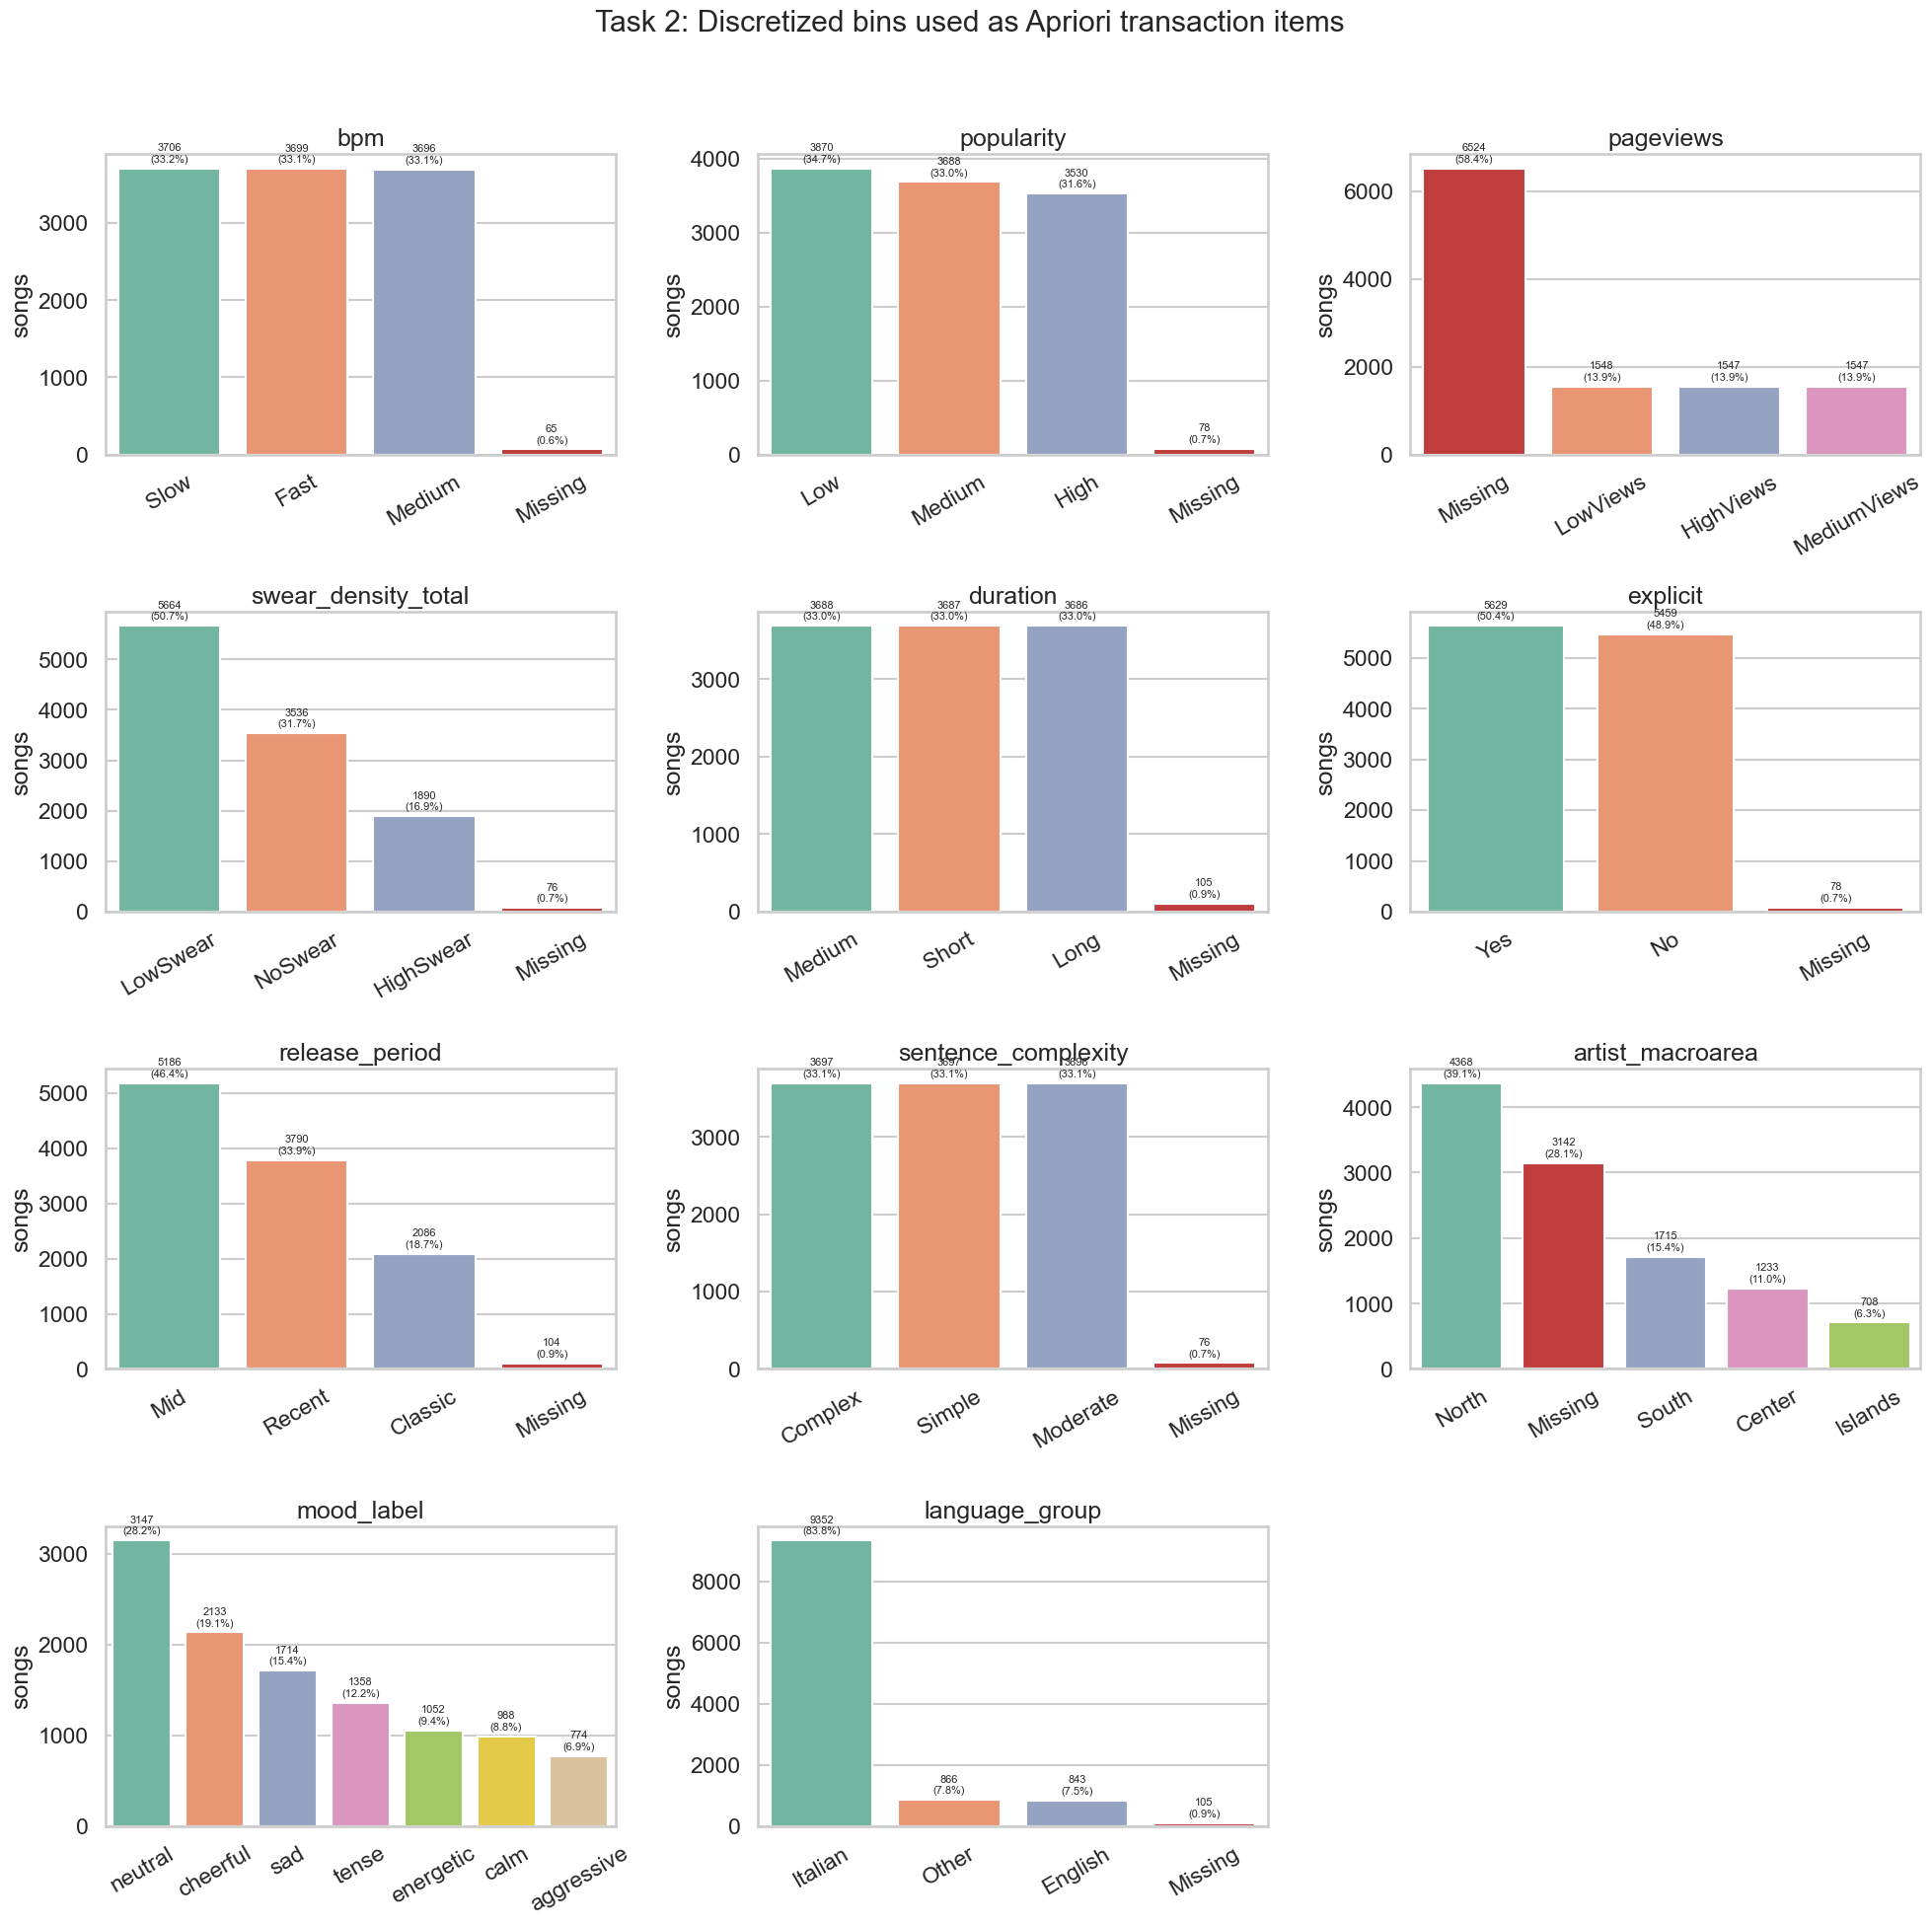

In [92]:
# Task 2.2 — Visual check of the discretized transaction items

plot_columns = discretized_columns
n_cols = 3
n_rows = int(np.ceil(len(plot_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4.8 * n_rows))
axes = np.array(axes).reshape(-1)

colors = sns.color_palette("Set2", n_colors=len(plot_columns))
missing_color = "#d62728"  # Red for missing values
for i, col in enumerate(plot_columns):
    ax = axes[i]
    counts = (
        apriori_df[col]
        .astype("string")
        .fillna("Missing")
        .value_counts()
        .sort_values(ascending=False)
    )
    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        hue=counts.index.astype(str),
        ax=ax,
        palette=[missing_color if val == "Missing" else colors[i] for i, val in enumerate(counts.index)],
        legend=False
    )
    ax.set_title(col.replace("disc_", ""))
    ax.set_xlabel("")
    ax.set_ylabel("songs")
    ax.tick_params(axis="x", rotation=30)

    total = counts.sum()
    max_count = counts.max()
    for x, y in enumerate(counts.values):
        ax.text(
            x,
            y + max_count * 0.015,
            f"{int(y)}\n({100 * y / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
        )

for j in range(len(plot_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Task 2: Discretized bins used as Apriori transaction items", y=1.02)
plt.tight_layout()
plt.show()


In [93]:
# Task 2.3 - Transaction encoding and association rule mining with mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules as mlxtend_association_rules


# Build transaction list (one basket per song), then one-hot encode with TransactionEncoder.
transactions = [
    uf.row_to_transaction(apriori_df.loc[idx], discretized_columns)
    for idx in apriori_df.index
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_matrix = pd.DataFrame(te_array, columns=te.columns_, index=apriori_df.index).astype(bool)

# Mining parameters.
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.55
MIN_LIFT = 1.15language_group=Italian

# Frequent itemsets with Apriori (mlxtend).
frequent_itemsets = apriori(
    transaction_matrix,
    min_support=MIN_SUPPORT,
    use_colnames=True,
).sort_values(["support", "itemsets"], ascending=[False, True]).reset_index(drop=True)

# Rules from frequent itemsets (confidence threshold first), then lift filter.
if frequent_itemsets.empty:
    association_rules = pd.DataFrame(
        columns=[
            "antecedents",language_group=Italian
            "consequents",
            "antecedent support",
            "consequent support",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
        ]
    )
else:
    association_rules = mlxtend_association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=MIN_CONFIDENCE,
        num_itemsets=len(transaction_matrix.index),
    )
    association_rules = association_rules[association_rules["lift"] >= MIN_LIFT].copy()

# Post-process rules for better readability and sorting, only if there are rules to process after filtering.
if not association_rules.empty:
    association_rules["antecedents"] = association_rules["antecedents"].map(frozenset)
    association_rules["consequents"] = association_rules["consequents"].map(frozenset)
    association_rules["antecedents_str"] = association_rules["antecedents"].map(
        lambda x: " ∧ ".join(sorted(x))
    )
    association_rules["consequents_str"] = association_rules["consequents"].map(
        lambda x: " ∧ ".join(sorted(x))
    )
    association_rules["antecedent"] = association_rules["antecedents"].map(
        lambda x: ", ".join(sorted(x))
    )
    association_rules["consequent"] = association_rules["consequents"].map(
        lambda x: ", ".join(sorted(x))
    )
    association_rules["rule_pretty"] = (
        association_rules["antecedents_str"] + " => " + association_rules["consequents_str"]
    )
    association_rules["antecedent_len"] = association_rules["antecedents"].map(len)
    association_rules["consequent_len"] = association_rules["consequents"].map(len)
    association_rules = association_rules.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

mining_summary = pd.DataFrame(
    {
        "metric": [
            "transactions",
            "candidate_items_after_missing_drop",
            "min_support",
            "min_confidence",
            "min_lift",
            "frequent_itemsets",
            "association_rules",
        ],
        "value": [
            len(transaction_matrix),
            transaction_matrix.shape[1],
            MIN_SUPPORT,
            MIN_CONFIDENCE,
            MIN_LIFT,
            len(frequent_itemsets),
            len(association_rules),
        ],
    }
)

frequent_itemset_summary = (
    frequent_itemsets.assign(length=frequent_itemsets["itemsets"].map(len))
    .groupby("length")
    .agg(
        n_itemsets=("itemsets", "size"),
        max_support=("support", "max"),
        min_support=("support", "min"),
    )
    .reset_index()
)

display(mining_summary)
display(frequent_itemset_summary)
display(
    frequent_itemsets.assign(itemset_str=frequent_itemsets["itemsets"].map(lambda x: " ∧ ".join(sorted(x))))
    .head(25)[["itemset_str", "support"]]
 )

columns_to_show = [
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

if association_rules.empty:
    rules_for_display = pd.DataFrame(columns=columns_to_show)
else:
    rules_for_display = association_rules[columns_to_show].copy()
    for col in ["support", "confidence", "lift", "leverage", "conviction"]:
        rules_for_display[col] = rules_for_display[col].round(3)

display(rules_for_display.head(30))

# Confidence-based association rules representation (top 10, parallel to lift visualization).
if association_rules.empty:
    print("Confidence view: no rules passed the mining thresholds.")
else:
    confidence_rules_display = association_rules.copy()
    top_confidence_rules = confidence_rules_display.nlargest(10, "confidence").copy()
    max_rule_label_chars = 50
    top_confidence_rules["rule_pretty_short"] = top_confidence_rules["rule_pretty"].map(
        lambda s: s if len(s) <= max_rule_label_chars else s[: max_rule_label_chars - 1] + "…"
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    confidence_cmap = sns.color_palette("mako", as_cmap=True)
    confidence_values = top_confidence_rules["confidence"].to_numpy()
    confidence_min = confidence_values.min()
    confidence_max = confidence_values.max()
    confidence_norm = mcolors.Normalize(
        vmin=confidence_min,
        vmax=confidence_max if confidence_max > confidence_min else confidence_min + 1e-9,
    )
    axes[0].barh(
        top_confidence_rules["rule_pretty_short"],
        confidence_values,
        color=confidence_cmap(confidence_norm(confidence_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title("Top 10 Association Rules by Confidence", fontsize=12)
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Rule")
    axes[0].tick_params(axis="y", labelsize=8)

    scatter = axes[1].scatter(
        confidence_rules_display["support"],
        confidence_rules_display["lift"],
        c=confidence_rules_display["confidence"],
        s=confidence_rules_display["confidence"] * 220,
        cmap="mako",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Confidence Distribution Across Rules", fontsize=12)
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Lift")
    cbar = fig.colorbar(scatter, ax=axes[1])
    cbar.set_label("Confidence")

    plt.tight_layout()
    plt.show()

    confidence_table = top_confidence_rules[columns_to_show].copy()
    for col in ["support", "confidence", "lift", "leverage", "conviction"]:
        confidence_table[col] = confidence_table[col].round(3)
    display(confidence_table)

    print("Extended confidence view (top 10):")
    for idx, row in top_confidence_rules.iterrows():
        print(
            f"{idx + 1:>2}. {row['rule_pretty']} | support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

SyntaxError: invalid decimal literal (3292205233.py, line 20)

We also try using a different metric, like lift to see what happens.

/tmp/ipykernel_5849/2743502392.py:66: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/home/simone/miniconda3/envs/ML_first_project/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


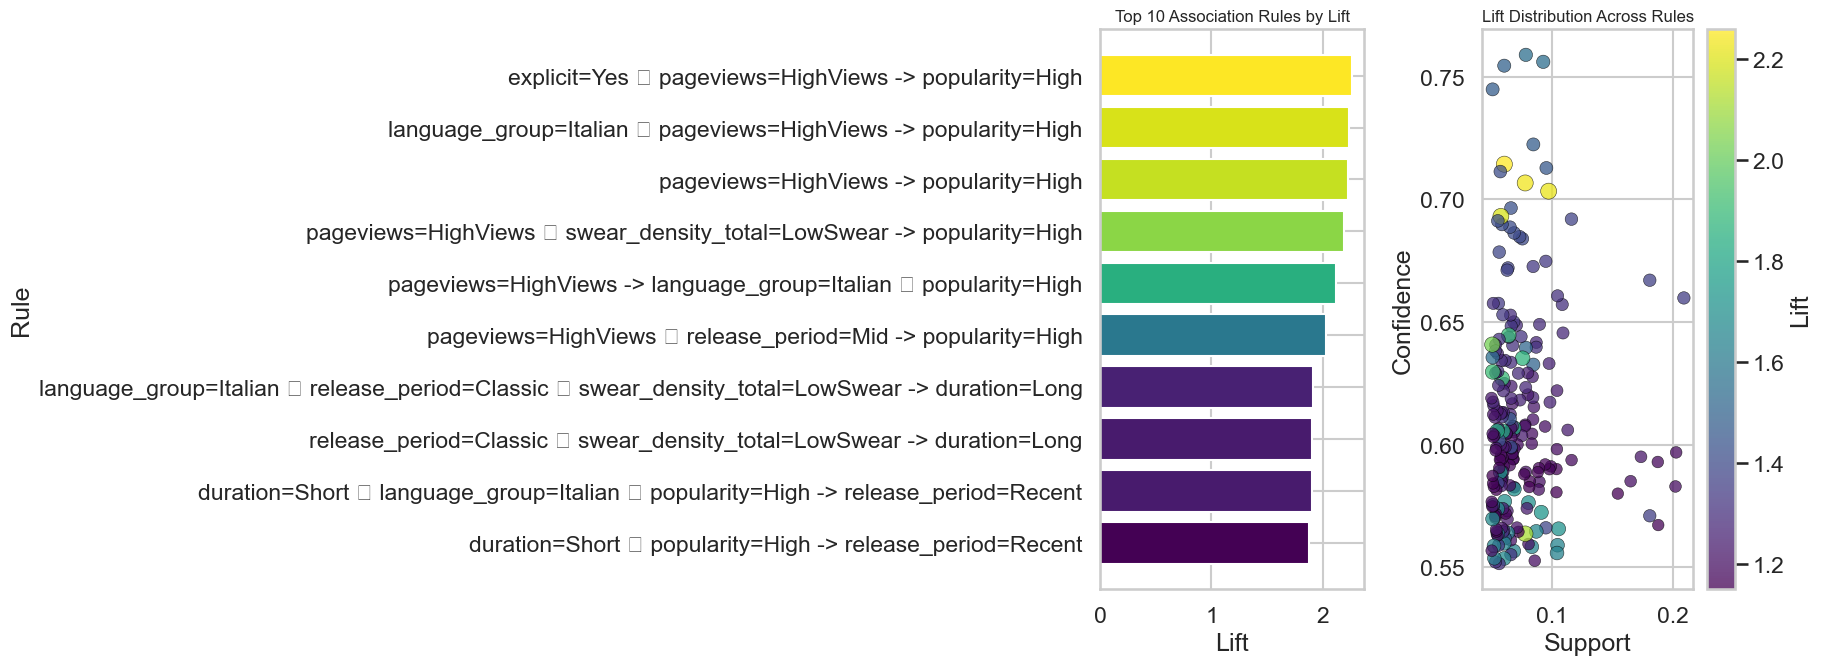

,antecedents,consequents,support,confidence,lift
812,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.060899,0.714286,2.259409
327,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078094,0.706645,2.235240
123,pageviews=HighViews,popularity=High,0.097439,0.703297,2.224649
1020,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058033,0.693048,2.192231
329,pageviews=HighViews,language_group=Italian ∧ popularity=High,0.078094,0.563672,2.116327
1575,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.050958,0.640766,2.026853
1525,language_group=Italian ∧ release_period=Classi...,duration=Long,0.051316,0.629670,1.907460
949,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059018,0.627022,1.899437
672,duration=Short ∧ language_group=Italian ∧ popu...,release_period=Recent,0.064481,0.644584,1.899056
364,duration=Short ∧ popularity=High,release_period=Recent,0.075945,0.635206,1.871427


In [ ]:
rules_lift = mlxtend_association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT,
    num_itemsets=len(transaction_matrix.index),
)
rules_lift = rules_lift[rules_lift["confidence"] >= MIN_CONFIDENCE].copy()

# Lift-based association rules representation
if rules_lift.empty:
    print("No rules satisfied the lift/confidence thresholds.")
else:
    rules_lift_display = rules_lift.copy()
    rules_lift_display["antecedent_label"] = rules_lift_display["antecedents"].apply(
        lambda x: " ∧ ".join(sorted(list(x)))
    )
    rules_lift_display["consequent_label"] = rules_lift_display["consequents"].apply(
        lambda x: " ∧ ".join(sorted(list(x)))
    )
    rules_lift_display["rule_label"] = (
        rules_lift_display["antecedent_label"]
        + " -> "
        + rules_lift_display["consequent_label"]
    )

    top_n = min(10, len(rules_lift_display))
    top_lift_rules = rules_lift_display.nlargest(top_n, "lift").copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 1) Top lift rules (bar chart)
    lift_cmap = sns.color_palette("viridis", as_cmap=True)
    lift_values = top_lift_rules["lift"].to_numpy()
    lift_min = lift_values.min()
    lift_max = lift_values.max()
    lift_norm = mcolors.Normalize(
        vmin=lift_min,
        vmax=lift_max if lift_max > lift_min else lift_min + 1e-9,
    )
    axes[0].barh(
        top_lift_rules["rule_label"],
        lift_values,
        color=lift_cmap(lift_norm(lift_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title(f"Top {top_n} Association Rules by Lift", fontsize=12)
    axes[0].set_xlabel("Lift")
    axes[0].set_ylabel("Rule")

    # 2) Rule landscape: support vs confidence, color = lift
    scatter = axes[1].scatter(
        rules_lift_display["support"],
        rules_lift_display["confidence"],
        c=rules_lift_display["lift"],
        s=rules_lift_display["lift"] * 60,
        cmap="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Lift Distribution Across Rules", fontsize=12)
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Confidence")
    cbar = fig.colorbar(scatter, ax=axes[1])
    cbar.set_label("Lift")

    plt.tight_layout()
    plt.show()

    top_lift_table = top_lift_rules[[
        "antecedent_label",
        "consequent_label",
        "support",
        "confidence",
        "lift",
    ]].rename(
        columns={
            "antecedent_label": "antecedents",
            "consequent_label": "consequents",
        }
    )
    for col in ["support", "confidence", "lift"]:
        top_lift_table[col] = top_lift_table[col].round(3)
    display(top_lift_table)

    print("Extended lift view (top 10):")
    for idx, row in top_lift_rules.reset_index(drop=True).iterrows():
        print(
            f"{idx + 1:>2}. antecedents={row['antecedent_label']} | consequents={row['consequent_label']} | support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

In [ ]:
# Visual confrontation: Top-10 confidence-based rules vs Top-10 lift-based rules (two tables)

if "top_confidence_rules" not in locals() or "top_lift_rules" not in locals():
    print("Missing required variables: run the cells that generate top_confidence_rules and top_lift_rules first.")
else:
    def _items_to_text(items):
        return " ∧ ".join(sorted(list(items)))

    # --- Confidence table ---
    conf_top10 = top_confidence_rules.nlargest(10, "confidence").copy()
    conf_top10["antecedents_text"] = conf_top10["antecedents"].apply(_items_to_text)
    conf_top10["consequents_text"] = conf_top10["consequents"].apply(_items_to_text)
    conf_top10["rule_key"] = list(zip(conf_top10["antecedents_text"], conf_top10["consequents_text"]))

    conf_view = conf_top10[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].copy()
    conf_view = conf_view.rename(
        columns={
            "antecedents_text": "antecedents",
            "consequents_text": "consequents",
            }
    )
    conf_view.insert(0, "rank_confidence", range(1, len(conf_view) + 1))

    # --- Lift table ---
    lift_top10 = top_lift_rules.nlargest(10, "lift").copy()
    lift_top10["antecedents_text"] = lift_top10["antecedents"].apply(_items_to_text)
    lift_top10["consequents_text"] = lift_top10["consequents"].apply(_items_to_text)
    lift_top10["rule_key"] = list(zip(lift_top10["antecedents_text"], lift_top10["consequents_text"]))

    lift_view = lift_top10[["antecedents_text", "consequents_text", "support", "confidence", "lift"]].copy()
    lift_view = lift_view.rename(
        columns={
            "antecedents_text": "antecedents",
            "consequents_text": "consequents",
        }
    )
    lift_view.insert(0, "rank_lift", range(1, len(lift_view) + 1))

    # Cross-reference (shared rules across top-10 lists)
    conf_rule_set = set(conf_top10["rule_key"])
    lift_rule_set = set(lift_top10["rule_key"])
    conf_view["in_lift_top10"] = conf_top10["rule_key"].isin(lift_rule_set)
    lift_view["in_conf_top10"] = lift_top10["rule_key"].isin(conf_rule_set)

    for c in ["support", "confidence", "lift"]:
        conf_view[c] = conf_view[c].round(3)
        lift_view[c] = lift_view[c].round(3)

    print("Top 10 rules by CONFIDENCE")
    display(conf_view)

    print("Top 10 rules by LIFT")
    display(lift_view)

Top 10 rules by CONFIDENCE


,rank_confidence,antecedents,consequents,support,confidence,lift,in_lift_top10
32,1,language_group=Italian ∧ popularity=Low ∧ swea...,explicit=No,0.079,0.759,1.552,False
34,2,popularity=Low ∧ swear_density_total=NoSwear,explicit=No,0.093,0.756,1.546,False
37,3,popularity=High ∧ release_period=Recent ∧ swea...,explicit=Yes,0.061,0.754,1.497,False
39,4,language_group=Italian ∧ popularity=High ∧ rel...,explicit=Yes,0.051,0.745,1.477,False
38,5,language_group=Italian ∧ sentence_complexity=S...,explicit=No,0.085,0.722,1.478,False
0,6,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.061,0.714,2.259,True
41,7,sentence_complexity=Simple ∧ swear_density_tot...,explicit=No,0.096,0.713,1.458,False
48,8,duration=Short ∧ release_period=Recent ∧ swear...,explicit=Yes,0.058,0.711,1.411,False
1,9,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078,0.707,2.235,True
2,10,pageviews=HighViews,popularity=High,0.097,0.703,2.225,True


Top 10 rules by LIFT


,rank_lift,antecedents,consequents,support,confidence,lift,in_conf_top10
812,1,explicit=Yes ∧ pageviews=HighViews,popularity=High,0.061,0.714,2.259,True
327,2,language_group=Italian ∧ pageviews=HighViews,popularity=High,0.078,0.707,2.235,True
123,3,pageviews=HighViews,popularity=High,0.097,0.703,2.225,True
1020,4,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058,0.693,2.192,False
329,5,pageviews=HighViews,language_group=Italian ∧ popularity=High,0.078,0.564,2.116,False
1575,6,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.051,0.641,2.027,False
1525,7,language_group=Italian ∧ release_period=Classi...,duration=Long,0.051,0.630,1.907,False
949,8,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,0.627,1.899,False
672,9,duration=Short ∧ language_group=Italian ∧ popu...,release_period=Recent,0.064,0.645,1.899,False
364,10,duration=Short ∧ popularity=High,release_period=Recent,0.076,0.635,1.871,False


Drop explicit and language from the rule mining, as they are not relevant for the pattern mining and may introduce noise due to their high cardinality and potential redundancy with other features. We prioritize lift based analysis as the rules generated with confidence as metric are not very interesting, as they mostly capture very high confidence rules with low lift, which are not very informative for our purposes. By using lift, we can identify rules that have a stronger association than expected by chance, which can provide more actionable insights for feature engineering.

,metric,value
0,transactions,11166.00
1,items_after_drop,32.00
2,min_support,0.05
3,min_confidence,0.55
4,min_lift,1.15
5,frequent_itemsets,425.00
6,rules,23.00


/tmp/ipykernel_5849/2121005504.py:112: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  plt.tight_layout()
/home/simone/miniconda3/envs/ML_first_project/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


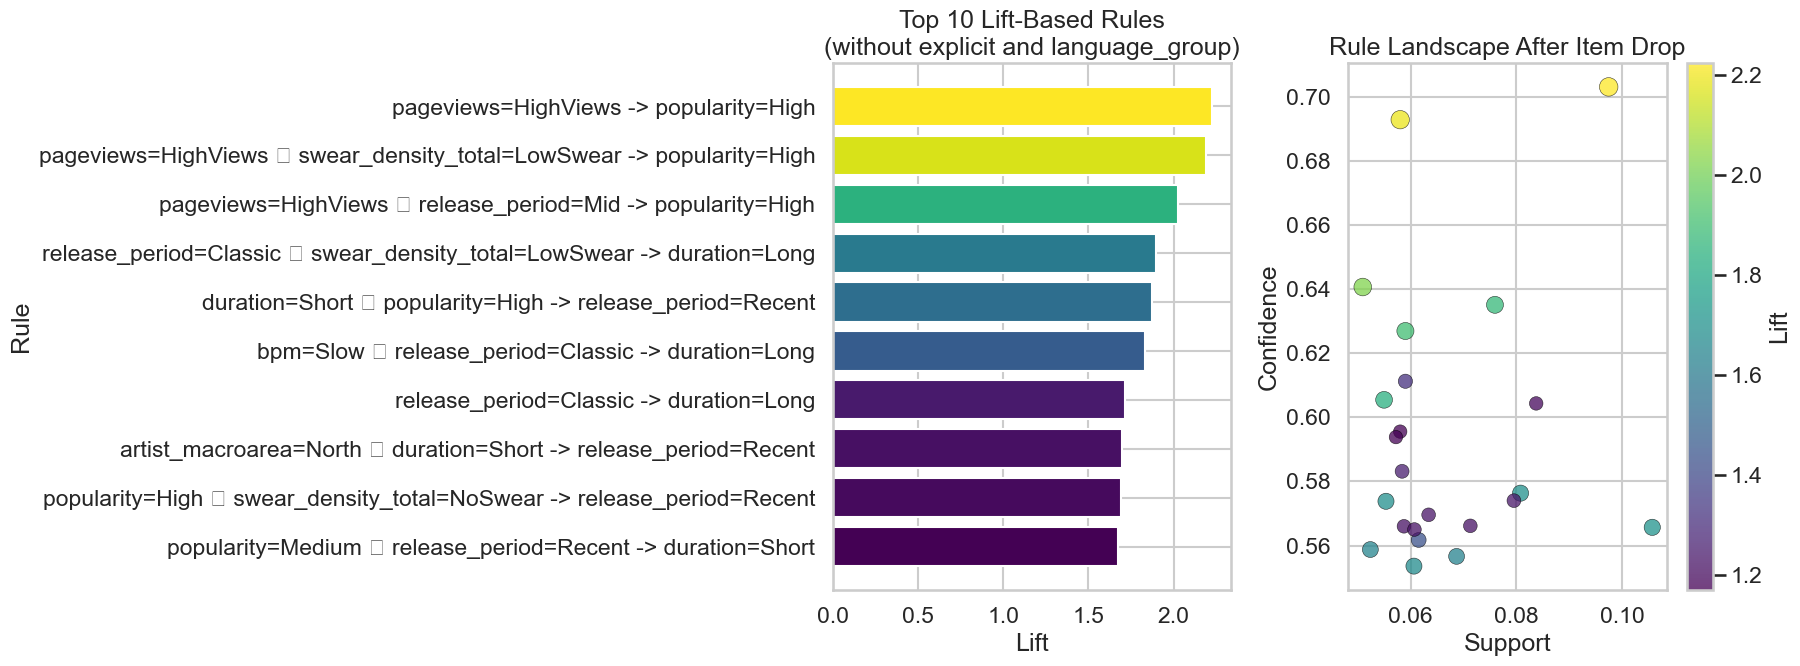

,antecedents,consequents,support,confidence,lift
0,pageviews=HighViews,popularity=High,0.097,0.703,2.225
1,pageviews=HighViews ∧ swear_density_total=LowS...,popularity=High,0.058,0.693,2.192
2,pageviews=HighViews ∧ release_period=Mid,popularity=High,0.051,0.641,2.027
3,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,0.627,1.899
4,duration=Short ∧ popularity=High,release_period=Recent,0.076,0.635,1.871
5,bpm=Slow ∧ release_period=Classic,duration=Long,0.055,0.606,1.834
6,release_period=Classic,duration=Long,0.106,0.566,1.714
7,artist_macroarea=North ∧ duration=Short,release_period=Recent,0.081,0.576,1.698
8,popularity=High ∧ swear_density_total=NoSwear,release_period=Recent,0.055,0.574,1.691
9,popularity=Medium ∧ release_period=Recent,duration=Short,0.061,0.554,1.676


Top lift-based rules after dropping explicit and language_group:
 1. pageviews=HighViews -> popularity=High | support=0.097, confidence=0.703, lift=2.225
 2. pageviews=HighViews ∧ swear_density_total=LowSwear -> popularity=High | support=0.058, confidence=0.693, lift=2.192
 3. pageviews=HighViews ∧ release_period=Mid -> popularity=High | support=0.051, confidence=0.641, lift=2.027
 4. release_period=Classic ∧ swear_density_total=LowSwear -> duration=Long | support=0.059, confidence=0.627, lift=1.899
 5. duration=Short ∧ popularity=High -> release_period=Recent | support=0.076, confidence=0.635, lift=1.871
 6. bpm=Slow ∧ release_period=Classic -> duration=Long | support=0.055, confidence=0.606, lift=1.834
 7. release_period=Classic -> duration=Long | support=0.106, confidence=0.566, lift=1.714
 8. artist_macroarea=North ∧ duration=Short -> release_period=Recent | support=0.081, confidence=0.576, lift=1.698
 9. popularity=High ∧ swear_density_total=NoSwear -> release_period=Recent | supp

In [ ]:
# Re-mine association rules after dropping explicit and language_group items
drop_prefixes = ("explicit=", "language_group=")

transaction_matrix_reduced = transaction_matrix.loc[
    :,
    ~transaction_matrix.columns.str.startswith(drop_prefixes),
].copy()

min_support = MIN_SUPPORT if "MIN_SUPPORT" in locals() else 0.05
min_confidence = MIN_CONFIDENCE if "MIN_CONFIDENCE" in locals() else 0.55
min_lift = MIN_LIFT if "MIN_LIFT" in locals() else 1.15

frequent_itemsets_reduced = apriori(
    transaction_matrix_reduced,
    min_support=min_support,
    use_colnames=True,
).sort_values(["support", "itemsets"], ascending=[False, True]).reset_index(drop=True)

if frequent_itemsets_reduced.empty:
    rules_lift_reduced = pd.DataFrame()
    print("No frequent itemsets found after dropping explicit and language_group.")
else:
    rules_lift_reduced = mlxtend_association_rules(
        frequent_itemsets_reduced,
        metric="lift",
        min_threshold=min_lift,
        num_itemsets=len(transaction_matrix_reduced),
    )
    rules_lift_reduced = rules_lift_reduced[
        rules_lift_reduced["confidence"] >= min_confidence
    ].copy()

if rules_lift_reduced.empty:
    print("No rules satisfied the lift/confidence thresholds after dropping explicit and language_group.")
else:
    rules_lift_reduced["antecedent_label"] = rules_lift_reduced["antecedents"].apply(
        lambda x: " ∧ ".join(sorted(x))
    )
    rules_lift_reduced["consequent_label"] = rules_lift_reduced["consequents"].apply(
        lambda x: " ∧ ".join(sorted(x))
    )
    rules_lift_reduced["rule_label"] = (
        rules_lift_reduced["antecedent_label"] + " -> " + rules_lift_reduced["consequent_label"]
    )
    rules_lift_reduced = rules_lift_reduced.sort_values(
        ["lift", "confidence", "support"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    mining_summary_reduced = pd.DataFrame(
        {
            "metric": [
                "transactions",
                "items_after_drop",
                "min_support",
                "min_confidence",
                "min_lift",
                "frequent_itemsets",
                "rules",
            ],
            "value": [
                len(transaction_matrix_reduced),
                transaction_matrix_reduced.shape[1],
                min_support,
                min_confidence,
                min_lift,
                len(frequent_itemsets_reduced),
                len(rules_lift_reduced),
            ],
        }
    )
    display(mining_summary_reduced)

    top_n = min(10, len(rules_lift_reduced))
    top_lift_rules_reduced = rules_lift_reduced.head(top_n).copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    lift_values = top_lift_rules_reduced["lift"].to_numpy()
    lift_norm = mcolors.Normalize(
        vmin=lift_values.min(),
        vmax=lift_values.max() if lift_values.max() > lift_values.min() else lift_values.min() + 1e-9,
    )
    lift_cmap = sns.color_palette("viridis", as_cmap=True)

    axes[0].barh(
        top_lift_rules_reduced["rule_label"],
        top_lift_rules_reduced["lift"],
        color=lift_cmap(lift_norm(lift_values)),
    )
    axes[0].invert_yaxis()
    axes[0].set_title(f"Top {top_n} Lift-Based Rules\n(without explicit and language_group)")
    axes[0].set_xlabel("Lift")
    axes[0].set_ylabel("Rule")

    scatter_reduced = axes[1].scatter(
        rules_lift_reduced["support"],
        rules_lift_reduced["confidence"],
        c=rules_lift_reduced["lift"],
        s=rules_lift_reduced["lift"] * 80,
        cmap="viridis",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
    )
    axes[1].set_title("Rule Landscape After Item Drop")
    axes[1].set_xlabel("Support")
    axes[1].set_ylabel("Confidence")
    cbar = fig.colorbar(scatter_reduced, ax=axes[1])
    cbar.set_label("Lift")

    plt.tight_layout()
    plt.show()

    rules_lift_reduced_display = top_lift_rules_reduced[
        ["antecedent_label", "consequent_label", "support", "confidence", "lift"]
    ].rename(
        columns={
            "antecedent_label": "antecedents",
            "consequent_label": "consequents",
        }
    )
    for col in ["support", "confidence", "lift"]:
        rules_lift_reduced_display[col] = rules_lift_reduced_display[col].round(3)

    display(rules_lift_reduced_display)

    print("Top lift-based rules after dropping explicit and language_group:")
    for i, row in top_lift_rules_reduced.reset_index(drop=True).iterrows():
        print(
            f"{i + 1:>2}. {row['rule_label']} | "
            f"support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}"
        )

## Retrieving The Most Interesting Association Rules

After comparing confidence-based rules, lift-based rules, and the reduced mining setup without `explicit` and `language_group`, we adopt the reduced lift-based mining result as the canonical source for interpretation. This choice is more defensible because it removes high-frequency shortcut items and keeps rules that are more likely to reflect non-trivial co-occurrence structure.

In this step, we do not simply take the top rules by a single metric. Instead, we apply a staged selection process designed to balance interpretability, usefulness, and statistical interest:

- keep only rules whose consequents are relevant for downstream analysis (`popularity`, `release_period`, `duration`, `mood_label`, `swear_density_total`)
- enforce minimum thresholds on support, confidence, lift, and leverage
- limit antecedent complexity to short and interpretable rules
- compute a novelty measure, defined as `confidence - consequent_support`, to capture how much the antecedent improves over the baseline rate of the consequent
- prune redundant longer rules when they do not add enough confidence compared with a simpler subset rule
- rank surviving rules with a composite interestingness score that combines lift, novelty, leverage, and support
- diversify the final shortlist so it is not dominated by multiple near-duplicate rules with the same consequent

The final output is therefore a compact set of rules that are more suitable for discussion in the report and more realistic candidates for later unsupervised learning.

In [ ]:
# Task 2.4 — Retrieve interesting association rules from the reduced lift-based mining

if "rules_lift_reduced" not in locals() or rules_lift_reduced.empty:
    print("No reduced lift-based rules available. Run the previous reduced mining cell first.")
else:
    canonical_rules = rules_lift_reduced.copy()
    n_transactions_reduced = len(transaction_matrix_reduced)

    target_prefixes = (
        "popularity=",
        "release_period=",
        "duration=",
        "mood_label=",
        "swear_density_total=",
    )

    min_support_interesting = 0.03
    min_confidence_interesting = 0.45
    min_lift_interesting = 1.20
    min_leverage_interesting = 0.005
    max_antecedent_len = 2
    min_confidence_gain = 0.05
    max_rules_per_consequent = 3

    def items_to_text(items):
        return " ∧ ".join(sorted(items))

    def has_target_consequent(consequents):
        return any(any(item.startswith(prefix) for prefix in target_prefixes) for item in consequents)

    def zscore_series(series):
        std = series.std(ddof=0)
        if pd.isna(std) or std == 0:
            return pd.Series(0.0, index=series.index)
        return (series - series.mean()) / std

    interesting_rules = canonical_rules.copy()
    interesting_rules["antecedent_len"] = interesting_rules["antecedents"].map(len)
    interesting_rules["consequent_len"] = interesting_rules["consequents"].map(len)
    interesting_rules["antecedents_text"] = interesting_rules["antecedents"].map(items_to_text)
    interesting_rules["consequents_text"] = interesting_rules["consequents"].map(items_to_text)
    interesting_rules["support_count"] = (interesting_rules["support"] * n_transactions_reduced).round().astype(int)
    interesting_rules["novelty"] = interesting_rules["confidence"] - interesting_rules["consequent support"]

    interesting_rules = interesting_rules[
        interesting_rules["consequents"].map(has_target_consequent)
        & (interesting_rules["support"] >= min_support_interesting)
        & (interesting_rules["confidence"] >= min_confidence_interesting)
        & (interesting_rules["lift"] >= min_lift_interesting)
        & (interesting_rules["leverage"] >= min_leverage_interesting)
        & (interesting_rules["antecedent_len"] <= max_antecedent_len)
    ].copy()

    if interesting_rules.empty:
        print("No rules passed the interestingness filters.")
    else:
        interesting_rules = interesting_rules.sort_values(
            ["consequents_text", "antecedent_len", "confidence", "lift", "support"],
            ascending=[True, True, False, False, False],
        ).reset_index(drop=True)

        confidence_lookup = {
            (frozenset(row["antecedents"]), frozenset(row["consequents"])): float(row["confidence"])
            for _, row in interesting_rules.iterrows()
        }

        redundancy_flags = []
        retention_reasons = []
        confidence_gains = []

        for _, row in interesting_rules.iterrows():
            antecedents = frozenset(row["antecedents"])
            consequents = frozenset(row["consequents"])

            if len(antecedents) <= 1:
                redundancy_flags.append(False)
                retention_reasons.append("base rule")
                confidence_gains.append(np.nan)
                continue

            subset_confidences = []
            for item in antecedents:
                subset = antecedents - {item}
                key = (subset, consequents)
                if key in confidence_lookup:
                    subset_confidences.append(confidence_lookup[key])

            if subset_confidences:
                best_subset_confidence = max(subset_confidences)
                confidence_gain = float(row["confidence"] - best_subset_confidence)
                is_redundant = confidence_gain < min_confidence_gain
                redundancy_flags.append(is_redundant)
                retention_reasons.append(
                    "adds signal over simpler rule" if not is_redundant else "redundant vs simpler rule"
                )
                confidence_gains.append(confidence_gain)
            else:
                redundancy_flags.append(False)
                retention_reasons.append("no simpler comparator found")
                confidence_gains.append(np.nan)

        interesting_rules["is_redundant"] = redundancy_flags
        interesting_rules["confidence_gain_vs_subset"] = confidence_gains
        interesting_rules["retention_reason"] = retention_reasons

        pruned_rules = interesting_rules.loc[~interesting_rules["is_redundant"]].copy()

        if pruned_rules.empty:
            print("All candidate rules were pruned as redundant. Consider relaxing the confidence-gain threshold.")
        else:
            pruned_rules["interestingness_score"] = (
                zscore_series(pruned_rules["lift"])
                + zscore_series(pruned_rules["novelty"])
                + zscore_series(pruned_rules["leverage"])
                + 0.5 * zscore_series(pruned_rules["support"])
            )

            pruned_rules = pruned_rules.sort_values(
                ["interestingness_score", "lift", "confidence", "support"],
                ascending=[False, False, False, False],
            ).reset_index(drop=True)

            diversified_rows = []
            consequent_counts = {}
            seen_rule_signatures = set()

            for _, row in pruned_rules.iterrows():
                consequent_text = row["consequents_text"]
                antecedent_text = row["antecedents_text"]
                signature = (antecedent_text, consequent_text)

                if signature in seen_rule_signatures:
                    continue
                if consequent_counts.get(consequent_text, 0) >= max_rules_per_consequent:
                    continue

                diversified_rows.append(row)
                seen_rule_signatures.add(signature)
                consequent_counts[consequent_text] = consequent_counts.get(consequent_text, 0) + 1

            final_interesting_rules = pd.DataFrame(diversified_rows).reset_index(drop=True)

            retrieval_summary = pd.DataFrame(
                {
                    "stage": [
                        "reduced lift-based rules",
                        "after target/quality filters",
                        "after redundancy pruning",
                        "final diversified shortlist",
                    ],
                    "n_rules": [
                        len(canonical_rules),
                        len(interesting_rules),
                        len(pruned_rules),
                        len(final_interesting_rules),
                    ],
                }
            )

            display(retrieval_summary)

            final_rules_view = final_interesting_rules[
                [
                    "antecedents_text",
                    "consequents_text",
                    "support",
                    "support_count",
                    "confidence",
                    "consequent support",
                    "novelty",
                    "lift",
                    "leverage",
                    "antecedent_len",
                    "confidence_gain_vs_subset",
                    "interestingness_score",
                    "retention_reason",
                ]
            ].rename(
                columns={
                    "antecedents_text": "antecedents",
                    "consequents_text": "consequents",
                    "consequent support": "consequent_support",
                }
            )

            for col in [
                "support",
                "confidence",
                "consequent_support",
                "novelty",
                "lift",
                "leverage",
                "confidence_gain_vs_subset",
                "interestingness_score",
            ]:
                final_rules_view[col] = final_rules_view[col].round(3)

            display(final_rules_view)

            print("Interesting rule shortlist:")
            for idx, row in final_rules_view.reset_index(drop=True).iterrows():
                print(
                    f"{idx + 1:>2}. antecedents={row['antecedents']} | consequents={row['consequents']} | "
                    f"support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}, novelty={row['novelty']:.3f}"
                )

            interesting_rules_selected = final_interesting_rules.copy()

,stage,n_rules
0,reduced lift-based rules,23
1,after target/quality filters,19
2,after redundancy pruning,16
3,final diversified shortlist,10


,antecedents,consequents,support,support_count,confidence,consequent_support,novelty,lift,leverage,antecedent_len,confidence_gain_vs_subset,interestingness_score,retention_reason
0,pageviews=HighViews,popularity=High,0.097,1088,0.703,0.316,0.387,2.225,0.054,1,NaN,7.890,base rule
1,release_period=Classic,duration=Long,0.106,1180,0.566,0.330,0.236,1.714,0.044,1,NaN,3.907,base rule
2,duration=Short ∧ popularity=High,release_period=Recent,0.076,848,0.635,0.339,0.296,1.871,0.035,2,NaN,3.444,no simpler comparator found
3,release_period=Classic ∧ swear_density_total=L...,duration=Long,0.059,659,0.627,0.330,0.297,1.899,0.028,2,0.061,2.382,adds signal over simpler rule
4,artist_macroarea=North ∧ duration=Short,release_period=Recent,0.081,902,0.576,0.339,0.237,1.698,0.033,2,NaN,2.163,no simpler comparator found
5,artist_macroarea=North ∧ popularity=High,release_period=Recent,0.069,767,0.557,0.339,0.217,1.640,0.027,2,NaN,0.813,no simpler comparator found
6,popularity=Medium ∧ release_period=Recent,duration=Short,0.061,677,0.554,0.330,0.223,1.676,0.024,2,NaN,0.547,no simpler comparator found
7,pageviews=HighViews,release_period=Mid,0.080,888,0.574,0.464,0.110,1.236,0.015,1,NaN,-2.367,base rule
8,bpm=Fast ∧ duration=Long,release_period=Mid,0.059,659,0.611,0.464,0.147,1.316,0.014,2,NaN,-2.433,no simpler comparator found
9,artist_macroarea=North ∧ popularity=Low,release_period=Mid,0.071,796,0.566,0.464,0.102,1.219,0.013,2,NaN,-2.986,no simpler comparator found


Interesting rule shortlist:
 1. antecedents=pageviews=HighViews | consequents=popularity=High | support=0.097, confidence=0.703, lift=2.225, novelty=0.387
 2. antecedents=release_period=Classic | consequents=duration=Long | support=0.106, confidence=0.566, lift=1.714, novelty=0.236
 3. antecedents=duration=Short ∧ popularity=High | consequents=release_period=Recent | support=0.076, confidence=0.635, lift=1.871, novelty=0.296
 4. antecedents=release_period=Classic ∧ swear_density_total=LowSwear | consequents=duration=Long | support=0.059, confidence=0.627, lift=1.899, novelty=0.297
 5. antecedents=artist_macroarea=North ∧ duration=Short | consequents=release_period=Recent | support=0.081, confidence=0.576, lift=1.698, novelty=0.237
 6. antecedents=artist_macroarea=North ∧ popularity=High | consequents=release_period=Recent | support=0.069, confidence=0.557, lift=1.640, novelty=0.217
 7. antecedents=popularity=Medium ∧ release_period=Recent | consequents=duration=Short | support=0.061, c

## Task 3 Preparation: Using Association Rules For Clustering

The rule-mining step is not used here as a replacement for clustering. Instead, it is used as a structured feature-selection layer before the unsupervised step. The goal is to convert only the most interpretable and sufficiently prevalent rule antecedents into candidate binary indicators, while leaving overly sparse or redundant rules for interpretation only.

This preparation step follows three principles:

- keep rule-derived indicators only when they have enough prevalence to influence cluster structure in a stable way
- avoid carrying multiple near-duplicate binary indicators into clustering
- preserve the remaining high-lift rules as descriptive tools for profiling clusters after the unsupervised model is fitted

The output therefore distinguishes between:

- `clustering_candidate`: rule-based indicators that are prevalent enough and non-redundant enough to be considered in Task 3
- `interpretation_only`: rules that are still interesting, but are better used to explain clusters than to define them

In [94]:
# Task 3 preparation — decide which rule-derived indicators should enter clustering

if "interesting_rules_selected" not in locals() or interesting_rules_selected.empty:
    print("No shortlisted interesting rules available. Run the previous rule-retrieval cell first.")
else:
    min_prevalence_for_clustering = 0.05
    max_prevalence_for_clustering = 0.40
    redundancy_threshold = 0.85

    task3_rule_feature_matrix = pd.DataFrame(index=df.index)
    strategy_rows = []

    rules_for_task3 = interesting_rules_selected.reset_index(drop=True).copy()

    for idx, row in rules_for_task3.iterrows():
        antecedent_items = sorted(list(row["antecedents"]))
        consequent_items = sorted(list(row["consequents"]))
        feature_name = f"rule_cluster_{idx + 1:02d}"

        feature_values = transaction_matrix_reduced[antecedent_items].all(axis=1).astype("int8")
        task3_rule_feature_matrix[feature_name] = feature_values

        prevalence = float(feature_values.mean())
        support_count = int(feature_values.sum())
        initial_role = (
            "eligible"
            if min_prevalence_for_clustering <= prevalence <= max_prevalence_for_clustering
            else "interpretation_only"
        )
        initial_reason = (
            "prevalence is compatible with clustering"
            if initial_role == "eligible"
            else "too sparse or too broad for stable clustering contribution"
        )

        strategy_rows.append(
            {
                "feature_name": feature_name,
                "antecedents": " ∧ ".join(antecedent_items),
                "consequents": " ∧ ".join(consequent_items),
                "positive_count": support_count,
                "positive_rate": prevalence,
                "support": float(row["support"]),
                "confidence": float(row["confidence"]),
                "lift": float(row["lift"]),
                "novelty": float(row["novelty"]),
                "interestingness_score": float(row["interestingness_score"]),
                "initial_role": initial_role,
                "initial_reason": initial_reason,
            }
        )

    task3_rule_feature_strategy = pd.DataFrame(strategy_rows)

    eligible_features = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["initial_role"] == "eligible", "feature_name"
    ].tolist()

    final_roles = {}
    final_reasons = {}

    if eligible_features:
        feature_corr = task3_rule_feature_matrix[eligible_features].corr().abs().fillna(0)
        ranked_candidates = task3_rule_feature_strategy.loc[
            task3_rule_feature_strategy["feature_name"].isin(eligible_features)
        ].sort_values(
            ["interestingness_score", "lift", "confidence", "support"],
            ascending=[False, False, False, False],
        )

        kept_features = []
        for feature_name in ranked_candidates["feature_name"]:
            if any(feature_corr.loc[feature_name, kept] >= redundancy_threshold for kept in kept_features):
                final_roles[feature_name] = "interpretation_only"
                final_reasons[feature_name] = "redundant with a stronger rule-derived indicator"
            else:
                kept_features.append(feature_name)
                final_roles[feature_name] = "clustering_candidate"
                final_reasons[feature_name] = "prevalent enough and not redundant with higher-ranked candidates"
    else:
        kept_features = []

    for _, row in task3_rule_feature_strategy.iterrows():
        feature_name = row["feature_name"]
        if feature_name not in final_roles:
            final_roles[feature_name] = "interpretation_only"
            final_reasons[feature_name] = row["initial_reason"]

    task3_rule_feature_strategy["task3_role"] = task3_rule_feature_strategy["feature_name"].map(final_roles)
    task3_rule_feature_strategy["task3_reason"] = task3_rule_feature_strategy["feature_name"].map(final_reasons)

    for col in ["positive_rate", "support", "confidence", "lift", "novelty", "interestingness_score"]:
        task3_rule_feature_strategy[col] = task3_rule_feature_strategy[col].round(3)

    task3_rule_features_for_clustering = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["task3_role"] == "clustering_candidate", "feature_name"
    ].tolist()
    task3_rule_features_for_interpretation = task3_rule_feature_strategy.loc[
        task3_rule_feature_strategy["task3_role"] == "interpretation_only", "feature_name"
    ].tolist()

    task3_rule_feature_summary = pd.DataFrame(
        {
            "metric": [
                "shortlisted_interesting_rules",
                "eligible_by_prevalence",
                "recommended_for_clustering",
                "kept_for_interpretation_only",
            ],
            "value": [
                len(task3_rule_feature_strategy),
                int((task3_rule_feature_strategy["initial_role"] == "eligible").sum()),
                len(task3_rule_features_for_clustering),
                len(task3_rule_features_for_interpretation),
            ],
        }
    )

    display(task3_rule_feature_summary)
    display(
        task3_rule_feature_strategy[
            [
                "feature_name",
                "antecedents",
                "consequents",
                "positive_count",
                "positive_rate",
                "support",
                "confidence",
                "lift",
                "novelty",
                "task3_role",
                "task3_reason",
            ]
        ].sort_values(["task3_role", "lift", "confidence"], ascending=[True, False, False]).reset_index(drop=True)
    )

    if task3_rule_features_for_clustering:
        recommended_rule_features_matrix = task3_rule_feature_matrix[task3_rule_features_for_clustering].copy()
        print("Recommended rule-derived features for Task 3 clustering:")
        print(task3_rule_features_for_clustering)
    else:
        recommended_rule_features_matrix = pd.DataFrame(index=df.index)
        print("No rule-derived features were recommended for clustering under the current thresholds.")

    print("Rule-derived features reserved for interpretation only:")
    print(task3_rule_features_for_interpretation)

,metric,value
0,shortlisted_interesting_rules,10
1,eligible_by_prevalence,10
2,recommended_for_clustering,9
3,kept_for_interpretation_only,1


,feature_name,antecedents,consequents,positive_count,positive_rate,support,confidence,lift,novelty,task3_role,task3_reason
0,rule_cluster_01,pageviews=HighViews,popularity=High,1547,0.139,0.097,0.703,2.225,0.387,clustering_candidate,prevalent enough and not redundant with higher...
1,rule_cluster_04,release_period=Classic ∧ swear_density_total=L...,duration=Long,1051,0.094,0.059,0.627,1.899,0.297,clustering_candidate,prevalent enough and not redundant with higher...
2,rule_cluster_03,duration=Short ∧ popularity=High,release_period=Recent,1335,0.120,0.076,0.635,1.871,0.296,clustering_candidate,prevalent enough and not redundant with higher...
3,rule_cluster_02,release_period=Classic,duration=Long,2086,0.187,0.106,0.566,1.714,0.236,clustering_candidate,prevalent enough and not redundant with higher...
4,rule_cluster_05,artist_macroarea=North ∧ duration=Short,release_period=Recent,1565,0.140,0.081,0.576,1.698,0.237,clustering_candidate,prevalent enough and not redundant with higher...
5,rule_cluster_07,popularity=Medium ∧ release_period=Recent,duration=Short,1223,0.110,0.061,0.554,1.676,0.223,clustering_candidate,prevalent enough and not redundant with higher...
6,rule_cluster_06,artist_macroarea=North ∧ popularity=High,release_period=Recent,1378,0.123,0.069,0.557,1.640,0.217,clustering_candidate,prevalent enough and not redundant with higher...
7,rule_cluster_09,bpm=Fast ∧ duration=Long,release_period=Mid,1078,0.097,0.059,0.611,1.316,0.147,clustering_candidate,prevalent enough and not redundant with higher...
8,rule_cluster_10,artist_macroarea=North ∧ popularity=Low,release_period=Mid,1406,0.126,0.071,0.566,1.219,0.102,clustering_candidate,prevalent enough and not redundant with higher...
9,rule_cluster_08,pageviews=HighViews,release_period=Mid,1547,0.139,0.080,0.574,1.236,0.110,interpretation_only,redundant with a stronger rule-derived indicator


Recommended rule-derived features for Task 3 clustering:
['rule_cluster_01', 'rule_cluster_02', 'rule_cluster_03', 'rule_cluster_04', 'rule_cluster_05', 'rule_cluster_06', 'rule_cluster_07', 'rule_cluster_09', 'rule_cluster_10']
Rule-derived features reserved for interpretation only:
['rule_cluster_08']


## Task 3 — Clustering With Engineered, Rule-Based, And Selected Original Features

This step runs three clustering algorithms used in the context materials (`KMeans`, hierarchical clustering, `DBSCAN`) on a unified feature space built from:

- all available engineered features from Task 1 (including engineered categorical variables via one-hot encoding)
- rule-based features selected as `clustering_candidate`
- a subset of original features: `bpm`, `popularity`, `stats_pageviews`, and `release_period` (from the discretized field)

Evaluation follows the same style used in the context notebooks, focusing on internal clustering quality:

- silhouette score (higher is better)
- Davies-Bouldin score (lower is better)
- cluster count and noise rate (for DBSCAN)

The goal is to compare cluster structure quality across algorithms under the same feature design.

In [96]:
# Task 3 — Unified clustering benchmark (K-Means, Hierarchical, DBSCAN)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

try:
    from sklearn import metrics
    metrics_available = True
except Exception:
    metrics = None
    metrics_available = False

# -------------------------
# 1) Build feature matrix
# -------------------------

original_subset = ["bpm", "popularity", "stats_pageviews"]
release_period_source = "disc_release_period" if "disc_release_period" in apriori_df.columns else None

# Engineered features documented in Task 1 + additional engineered categoricals if available.
engineered_feature_candidates = []
if "engineered_additions" in locals() and "feature" in engineered_additions.columns:
    engineered_feature_candidates.extend(engineered_additions["feature"].dropna().astype(str).tolist())
engineered_feature_candidates.extend([
    "mood_label",
    "artist_macroarea",
    "arousal_score_n",
    "valence_score_n",
])
engineered_feature_candidates = sorted(set(engineered_feature_candidates))
engineered_feature_candidates = [c for c in engineered_feature_candidates if c in df.columns]

# Rule-based features selected for clustering.
if "task3_rule_features_for_clustering" in locals() and len(task3_rule_features_for_clustering) > 0:
    selected_rule_features = [c for c in task3_rule_features_for_clustering if c in task3_rule_feature_matrix.columns]
elif "recommended_rule_features_matrix" in locals() and not recommended_rule_features_matrix.empty:
    selected_rule_features = list(recommended_rule_features_matrix.columns)
else:
    selected_rule_features = []

feature_build = pd.DataFrame(index=df.index)

# Add numeric original subset.
for col in original_subset:
    if col in df.columns:
        feature_build[col] = pd.to_numeric(df[col], errors="coerce")

# Add engineered features (numeric directly, categorical later).
categorical_candidates = []
for col in engineered_feature_candidates:
    if pd.api.types.is_numeric_dtype(df[col]):
        feature_build[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        categorical_candidates.append(col)

# Add release_period from the discretized apriori dataset (categorical).
if release_period_source is not None:
    categorical_candidates.append(release_period_source)

# One-hot encode categorical engineered/original subset fields.
onehot_parts = []
if categorical_candidates:
    cat_frame = pd.DataFrame(index=df.index)
    for col in categorical_candidates:
        if col == release_period_source:
            cat_frame[col] = apriori_df[col].astype("string")
        else:
            cat_frame[col] = df[col].astype("string")

    cat_frame = cat_frame.fillna("Missing")
    onehot_parts.append(pd.get_dummies(cat_frame, prefix=cat_frame.columns, dtype="int8"))

# Add rule-based binary features.
if selected_rule_features:
    rule_matrix = task3_rule_feature_matrix[selected_rule_features].copy()
    onehot_parts.append(rule_matrix.astype("int8"))

X_parts = [feature_build]
X_parts.extend(onehot_parts)
X_raw = pd.concat(X_parts, axis=1)

# Impute numeric missings with median (one-hot/rule columns are already complete).
for col in X_raw.columns:
    if pd.api.types.is_numeric_dtype(X_raw[col]) and X_raw[col].isna().any():
        X_raw[col] = X_raw[col].fillna(X_raw[col].median())

X_raw = X_raw.loc[:, ~X_raw.columns.duplicated()].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

onehot_feature_count = onehot_parts[0].shape[1] if onehot_parts else 0
rule_feature_count = len(selected_rule_features)
if len(onehot_parts) > 1:
    onehot_feature_count = sum(part.shape[1] for part in onehot_parts[:-1])

feature_space_summary = pd.DataFrame(
    {
        "component": [
            "original_numeric_subset",
            "engineered_features_numeric",
            "engineered_or_release_period_onehot",
            "rule_based_features",
            "total_features_after_encoding",
            "n_samples",
        ],
        "value": [
            len([c for c in original_subset if c in feature_build.columns]),
            len([c for c in engineered_feature_candidates if c in feature_build.columns and c not in original_subset]),
            onehot_feature_count,
            rule_feature_count,
            X_raw.shape[1],
            X_raw.shape[0],
        ],
    }
)

display(feature_space_summary)

# -------------------------
# 2) Cluster utilities
# -------------------------

def evaluate_partition(X, labels):
    labels = np.asarray(labels)
    valid_mask = labels != -1
    unique_all = np.unique(labels)
    unique_valid = np.unique(labels[valid_mask]) if valid_mask.any() else np.array([])

    n_clusters_total = int(len(unique_all) - (1 if -1 in unique_all else 0))
    noise_rate = float((labels == -1).mean()) if (-1 in unique_all) else 0.0

    if metrics_available and len(unique_valid) >= 2 and valid_mask.sum() > len(unique_valid):
        X_eval = X[valid_mask]
        labels_eval = labels[valid_mask]
        silhouette = float(metrics.silhouette_score(X_eval, labels_eval))
        davies_bouldin = float(metrics.davies_bouldin_score(X_eval, labels_eval))
    else:
        silhouette = np.nan
        davies_bouldin = np.nan

    return {
        "n_clusters": n_clusters_total,
        "noise_rate": noise_rate,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
    }

# -------------------------
# 3) Run clustering methods
# -------------------------

n_clusters = 3

# K-Means (same style as context notebook: n_init=10, max_iter=300)
kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_eval = evaluate_partition(X_scaled, kmeans_labels)
kmeans_eval["inertia"] = float(kmeans.inertia_)

# Hierarchical clustering (agglomerative, Ward linkage)
hier = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)
hier_eval = evaluate_partition(X_scaled, hier_labels)
hier_eval["inertia"] = np.nan

# DBSCAN with a small grid search on eps/min_samples, pick best silhouette among valid runs.
dbscan_candidates = []
for eps in [0.8, 1.0, 1.2, 1.4, 1.6]:
    for min_samples in [5, 8, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        eval_dict = evaluate_partition(X_scaled, labels)
        eval_dict.update({"eps": eps, "min_samples": min_samples, "labels": labels})
        dbscan_candidates.append(eval_dict)

dbscan_grid = pd.DataFrame(dbscan_candidates).drop(columns=["labels"])

valid_dbscan = [
    row for row in dbscan_candidates
    if (not pd.isna(row["silhouette"])) and row["n_clusters"] >= 2
]

if valid_dbscan:
    best_dbscan = sorted(valid_dbscan, key=lambda d: (d["silhouette"], -d["davies_bouldin"]), reverse=True)[0]
    dbscan_labels = best_dbscan["labels"]
    dbscan_eval = {
        "n_clusters": best_dbscan["n_clusters"],
        "noise_rate": best_dbscan["noise_rate"],
        "silhouette": best_dbscan["silhouette"],
        "davies_bouldin": best_dbscan["davies_bouldin"],
        "inertia": np.nan,
    }
    dbscan_best_params = {"eps": best_dbscan["eps"], "min_samples": best_dbscan["min_samples"]}
else:
    dbscan_labels = np.full(X_scaled.shape[0], -1)
    dbscan_eval = {
        "n_clusters": 0,
        "noise_rate": 1.0,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "inertia": np.nan,
    }
    dbscan_best_params = {"eps": np.nan, "min_samples": np.nan}

# -------------------------
# 4) Results summary
# -------------------------

clustering_results = pd.DataFrame(
    [
        {
            "algorithm": "KMeans",
            "n_clusters": kmeans_eval["n_clusters"],
            "noise_rate": kmeans_eval["noise_rate"],
            "silhouette": kmeans_eval["silhouette"],
            "davies_bouldin": kmeans_eval["davies_bouldin"],
            "inertia": kmeans_eval["inertia"],
            "params": f"n_clusters={n_clusters}, n_init=10, max_iter=300",
        },
        {
            "algorithm": "Hierarchical",
            "n_clusters": hier_eval["n_clusters"],
            "noise_rate": hier_eval["noise_rate"],
            "silhouette": hier_eval["silhouette"],
            "davies_bouldin": hier_eval["davies_bouldin"],
            "inertia": hier_eval["inertia"],
            "params": f"n_clusters={n_clusters}, linkage=ward",
        },
        {
            "algorithm": "DBSCAN",
            "n_clusters": dbscan_eval["n_clusters"],
            "noise_rate": dbscan_eval["noise_rate"],
            "silhouette": dbscan_eval["silhouette"],
            "davies_bouldin": dbscan_eval["davies_bouldin"],
            "inertia": dbscan_eval["inertia"],
            "params": f"eps={dbscan_best_params['eps']}, min_samples={dbscan_best_params['min_samples']}",
        },
    ]
)

for col in ["noise_rate", "silhouette", "davies_bouldin", "inertia"]:
    if col in clustering_results.columns:
        clustering_results[col] = clustering_results[col].round(4)

display(clustering_results)
display(dbscan_grid.round(4).sort_values(["silhouette", "n_clusters"], ascending=[False, False]).reset_index(drop=True))

# Persist labels for downstream profiling.
df["cluster_kmeans_task3"] = kmeans_labels
df["cluster_hierarchical_task3"] = hier_labels
df["cluster_dbscan_task3"] = dbscan_labels

if not metrics_available:
    print("Note: sklearn.metrics is unavailable in the current environment, so silhouette and Davies-Bouldin are NaN.")

print("Cluster label distributions:")
print("KMeans:")
print(pd.Series(kmeans_labels).value_counts(dropna=False).sort_index())
print("\nHierarchical:")
print(pd.Series(hier_labels).value_counts(dropna=False).sort_index())
print("\nDBSCAN (label -1 is noise):")
print(pd.Series(dbscan_labels).value_counts(dropna=False).sort_index())

ModuleNotFoundError: No module named 'sklearn.cluster'

## Discussion Notes For The Report

When writing the final report, discuss both descriptive findings and data limitations:

- `album` / `album_name` and `title` / `full_title` are redundancy candidates, but the richer text version was retained.
- Geography is informative but incomplete, so regional findings must be framed cautiously.
- Popularity and pageviews are likely skewed and should be interpreted with outlier awareness.
- Swear density is more comparable than raw swear counts because it adjusts for lyric length.
- The sentence complexity index is intentionally transparent: higher values mean longer, denser, and lexically richer sentences.
- The new engineered features (audio signature, artist consistency, engagement ratio, geographic diversity, etc.) provide interpretable axes for clustering and analysis, but their reliability depends on the underlying data quality.
- The valence-arousal mood label system is based on a weighted combination of normalized audio features, following academic Music Emotion Recognition (MER) practice. Arousal (energy) is more reliably captured by low-level features than valence (positivity), which is limited by the absence of harmony/lyrics/chroma data.
- Mood labels (energetic, cheerful, calm, sad, tense, aggressive, neutral) are assigned using quantile-based thresholds in the 2D valence-arousal space, providing an interpretable and literature-aligned segmentation for downstream analysis.
- All engineered features and mood labels should be interpreted as proxies: they are useful for clustering, visualization, and exploratory analysis, but not as definitive psychological or genre ground-truths.